In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd

from src.data import load_wikitext, get_continuous_text, get_prompt_batch
from src.model import load_model, load_tokenizer, print_model_config


/Users/raffaeledagostino/anaconda3/envs/master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load dataset, tokenizer, and model
train_data = load_wikitext('train')
tokenizer = load_tokenizer()
model = load_model()

Loading weights: 100%|██████████| 398/398 [00:01<00:00, 216.36it/s, Materializing param=model.norm.weight]                              
Some parameters are on the meta device because they were offloaded to the disk.


In [4]:
# printing model architecture
print_model_config(model)

=== Model Configuration ===
Number of layers:          36
Attention heads (Q):       32
Key-Value heads:           8
Hidden size:               2560
Intermediate size (FFN):   9728
Vocab size:                151936
Max position embeddings:   40960
Head dim:                  128


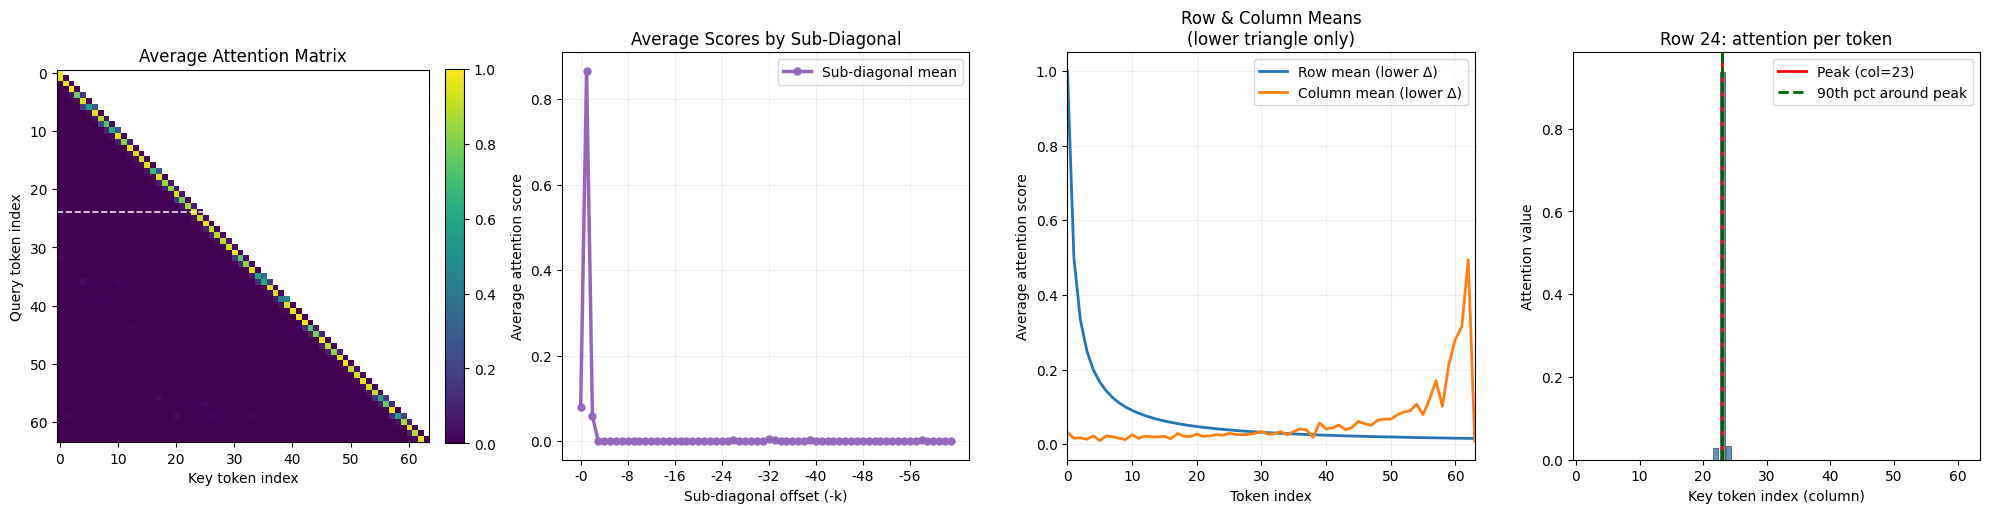

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def average_attention_matrix_over_prompts(
    model,
    tokenizer,
    prompts,
    layer_idx,
    head_idx,
    seq_len=128,
):
    """
    Compute average attention matrix for a chosen (layer, head) over multiple prompts.
    Returns a (T, T) matrix where T is the minimum sequence length observed.
    """
    device = next(model.parameters()).device
    collected = []

    model.eval()
    with torch.no_grad():
        for prompt in prompts:
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=seq_len,
                add_special_tokens=True,
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs, output_attentions=True, use_cache=False)
            # Shape per layer: [batch, heads, tokens, tokens]
            attn = outputs.attentions[layer_idx][0, head_idx].detach().float().cpu().numpy()
            collected.append(attn)

    if not collected:
        raise ValueError("No attention matrices were collected. Provide at least one prompt.")

    # Keep dimensions aligned if token lengths vary slightly across prompts.
    min_len = min(m.shape[0] for m in collected)
    cropped = [m[:min_len, :min_len] for m in collected]
    avg_attn = np.mean(cropped, axis=0)
    return avg_attn


def _weighted_percentile(values, weights, percentile):
    """Return weighted percentile for 1D arrays."""
    if len(values) == 0:
        return 0.0
    sort_idx = np.argsort(values)
    v = values[sort_idx]
    w = weights[sort_idx]
    w_sum = w.sum()
    if w_sum <= 0:
        return float(np.percentile(v, percentile))
    cdf = np.cumsum(w) / w_sum
    q = percentile / 100.0
    return float(np.interp(q, cdf, v))


def _print_row_col_stats(avg_attn, row_idx):
    """Print mean/median/std for each row and each column in lower triangle."""
    n = avg_attn.shape[0]

    print("\n=== Row Statistics (lower triangle: col <= row) ===")
    print(f"{'row':>4} | {'mean':>12} | {'median':>12} | {'std':>12}")
    print("-" * 52)
    for i in range(n):
        vals = avg_attn[i, : i + 1]
        print(f"{i:4d} | {vals.mean():12.6f} | {np.median(vals):12.6f} | {vals.std():12.6f}")

    print("\n=== Column Statistics (lower triangle: row >= col) ===")
    print(f"{'col':>4} | {'mean':>12} | {'median':>12} | {'std':>12}")
    print("-" * 52)
    for j in range(n):
        vals = avg_attn[j:, j]
        print(f"{j:4d} | {vals.mean():12.6f} | {np.median(vals):12.6f} | {vals.std():12.6f}")

    row_vals_full = avg_attn[row_idx, :]
    print("\n=== Selected Row Statistics (full row) ===")
    print(
        f"row={row_idx} | mean={row_vals_full.mean():.6f} | "
        f"median={np.median(row_vals_full):.6f} | std={row_vals_full.std():.6f}"
    )


def plot_attention_and_row_barplot(
    avg_attn,
    row_idx,
    percentile=90,
    cmap="viridis",
    print_stats=True,
):
    """
    Plot:
    1) average attention matrix,
    2) average scores for each sub-diagonal in lower triangle,
    3) row and column means from lower triangle,
    4) per-cell barplot for one selected row.
    """
    if row_idx < 0 or row_idx >= avg_attn.shape[0]:
        raise IndexError(f"row_idx={row_idx} out of bounds for matrix size {avg_attn.shape[0]}")

    n = avg_attn.shape[0]
    lower_mask = np.tril(np.ones((n, n), dtype=bool), k=0)

    # Lower triangle row/column means
    row_sums = (avg_attn * lower_mask).sum(axis=1)
    row_counts = lower_mask.sum(axis=1)
    row_means = row_sums / np.maximum(row_counts, 1)

    col_sums = (avg_attn * lower_mask).sum(axis=0)
    col_counts = lower_mask.sum(axis=0)
    col_means = col_sums / np.maximum(col_counts, 1)

    # Compute sub-diagonal averages for lower triangle
    diag_means = []
    for k in range(n):
        diag_vals = np.diag(avg_attn, k=-k)
        if len(diag_vals) > 0:
            diag_means.append(diag_vals.mean())

    if print_stats:
        _print_row_col_stats(avg_attn, row_idx)

    row_values = avg_attn[row_idx]
    x_idx = np.arange(len(row_values), dtype=float)

    peak_pos = int(np.argmax(row_values))

    # Symmetric percentile interval in index-space around the peak index.
    distances_idx = np.abs(x_idx - peak_pos)
    weights = np.maximum(row_values, 0.0) + 1e-12
    radius_idx = _weighted_percentile(distances_idx, weights, percentile)
    left_x = max(0.0, peak_pos - radius_idx)
    right_x = min(len(row_values) - 1.0, peak_pos + radius_idx)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Panel 1: Mask strict upper triangle and render it in white.
    upper_mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    attn_masked = np.ma.array(avg_attn, mask=upper_mask)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="white")

    im = axes[0].imshow(attn_masked, cmap=cmap_obj, aspect="equal")
    axes[0].set_title("Average Attention Matrix")
    axes[0].set_xlabel("Key token index")
    axes[0].set_ylabel("Query token index")
    axes[0].axhline(row_idx, color="white", linestyle="--", linewidth=1.2, alpha=0.9)
    axes[0].set_box_aspect(1)
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # Panel 2: Sub-diagonal averages
    axes[1].plot(range(len(diag_means)), diag_means, color="tab:purple", linewidth=2.5, 
                 marker="o", markersize=5, label="Sub-diagonal mean")
    axes[1].set_title("Average Scores by Sub-Diagonal")
    axes[1].set_xlabel("Sub-diagonal offset (-k)")
    axes[1].set_ylabel("Average attention score")
    axes[1].set_box_aspect(1)
    axes[1].grid(alpha=0.2)
    axes[1].set_xticks(range(0, len(diag_means), max(1, len(diag_means) // 8)))
    axes[1].set_xticklabels([f"-{i}" for i in range(0, len(diag_means), max(1, len(diag_means) // 8))])
    axes[1].legend()

    # Panel 3: Row and column means
    idx = np.arange(n)
    axes[2].plot(idx, row_means, color="tab:blue", linewidth=2, label="Row mean (lower Δ)")
    axes[2].plot(idx, col_means, color="tab:orange", linewidth=2, label="Column mean (lower Δ)")
    axes[2].set_title("Row & Column Means\n(lower triangle only)")
    axes[2].set_xlabel("Token index")
    axes[2].set_ylabel("Average attention score")
    axes[2].set_xlim(0, n - 1)
    axes[2].set_box_aspect(1)
    axes[2].grid(alpha=0.2)
    axes[2].legend()

    # Panel 4: Row barplot
    axes[3].bar(
        x_idx,
        row_values,
        color="steelblue",
        edgecolor="black",
        linewidth=0.4,
        alpha=0.85,
    )
    axes[3].axvline(peak_pos, color="red", linestyle="-", linewidth=2,
                    label=f"Peak (col={peak_pos})")
    axes[3].axvline(left_x, color="darkgreen", linestyle="--", linewidth=2,
                    label=f"{percentile}th pct around peak")
    axes[3].axvline(right_x, color="darkgreen", linestyle="--", linewidth=2)
    axes[3].set_title(f"Row {row_idx}: attention per token")
    axes[3].set_xlabel("Key token index (column)")
    axes[3].set_ylabel("Attention value")
    axes[3].set_xlim(-0.5, len(row_values) - 0.5)
    axes[3].set_box_aspect(1)
    axes[3].legend()

    plt.tight_layout()
    plt.show()


# -----------------------------
# Example usage (edit these)
# -----------------------------
n_prompts = 1
seq_len = 64
layer_idx = 0
head_idx = 1
row_idx = 24
percentile_x = 90

prompt_batch = get_prompt_batch(
    train_data,
    tokenizer,
    n_prompts=n_prompts,
    num_tokens=seq_len,
    stride=600,
    start_idx=1000,
)
prompts = [item[0] for item in prompt_batch]


avg_attn = average_attention_matrix_over_prompts(
    model=model,
    tokenizer=tokenizer,
    prompts=prompts,
    layer_idx=layer_idx,
    head_idx=head_idx,
    seq_len=seq_len,
)

plot_attention_and_row_barplot(
    avg_attn=avg_attn,
    row_idx=row_idx,
    percentile=percentile_x,
    cmap="viridis",
    print_stats=False,
)


In [24]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


@torch.inference_mode()
def plot_all_layers_attention(
    model,
    tokenizer,
    seq_len: int = 64,
    n_prompts: int = 10,
    seed: int = 42,
    output_dir: str = "./attention_maps",
    cmap: str = "viridis",
) -> None:
    """
    For every transformer layer, compute the average attention matrix over
    n_prompts random-token sequences and save a (n_rows x n_cols) grid of
    head attention matrices as a PNG.

    Parameters
    ----------
    model       : loaded CausalLM (eval mode recommended)
    tokenizer   : tokenizer matching the model
    seq_len     : token length of each random prompt
    n_prompts   : number of random prompts to average over
    seed        : RNG seed for reproducibility
    output_dir  : folder where PNGs will be written
    cmap        : matplotlib colormap for attention matrices
    """
    os.makedirs(output_dir, exist_ok=True)

    model.eval()
    device = next(model.parameters()).device

    cfg          = model.config
    num_layers   = int(cfg.num_hidden_layers)
    num_heads    = int(cfg.num_attention_heads)
    vocab_size   = int(getattr(tokenizer, "vocab_size", 0) or len(tokenizer))

    # Grid layout: closest rectangle with more columns than rows
    n_cols = 4
    n_rows = int(np.ceil(num_heads / n_cols))   # 8 for 32 heads
    rng = np.random.default_rng(seed)

    # Pre-generate all random prompts once: shape [n_prompts, seq_len]
    # This guarantees identical inputs across all layers
    all_input_ids = [
        torch.tensor(
            rng.integers(0, vocab_size, size=(seq_len,), dtype=np.int64),
            dtype=torch.long, device=device,
        ).unsqueeze(0)
        for _ in range(n_prompts)
    ]
    attention_mask = torch.ones((1, seq_len), dtype=torch.long, device=device)

    # Accumulate average attention: shape [num_layers, num_heads, seq_len, seq_len]
    # We use float64 for the accumulator to avoid precision loss across 10 prompts
    avg_attn = np.zeros((num_layers, num_heads, seq_len, seq_len), dtype=np.float64)

    for input_ids in tqdm(all_input_ids, desc="Averaging prompts"):
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
            use_cache=False,
        )
        # outputs.attentions: tuple of [num_layers] tensors, each [1, num_heads, seq, seq]
        for layer_idx, attn_tensor in enumerate(outputs.attentions):
            avg_attn[layer_idx] += (
                attn_tensor[0, :, :seq_len, :seq_len]
                .detach().float().cpu().numpy()
            )

    avg_attn /= n_prompts  # Normalize

    # =========================================================================
    # One figure per layer
    # =========================================================================
    for layer_idx in tqdm(range(num_layers), desc="Saving layer plots"):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
        fig.suptitle(
            f"Average Attention Matrices | Layer {layer_idx:02d} "
            f"| {n_prompts} random prompts | seq_len={seq_len}",
            fontsize=14, y=1.01
        )

        axes_flat = axes.flatten()

        for head_idx in range(num_heads):
            ax = axes_flat[head_idx]
            im = ax.imshow(avg_attn[layer_idx, head_idx], cmap=cmap, aspect="equal")
            ax.set_title(f"H{head_idx}", fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Hide any unused subplots (if num_heads is not a multiple of n_cols)
        for idx in range(num_heads, len(axes_flat)):
            axes_flat[idx].set_visible(False)

        plt.tight_layout()

        out_path = os.path.join(output_dir, f"layer_{layer_idx:02d}.png")
        fig.savefig(out_path, dpi=120, bbox_inches="tight")
        plt.close(fig)

    print(f"\n✓ Saved {num_layers} figures to '{output_dir}/'")


# Esecuzione:
plot_all_layers_attention(
    model=model,
    tokenizer=tokenizer,
    seq_len=64,
    n_prompts=1,
    seed=42,
    output_dir="./attention_maps",
    cmap="viridis",
)


Saving layer plots: 100%|██████████| 36/36 [00:36<00:00,  1.01s/it]


✓ Saved 36 figures to './attention_maps/'


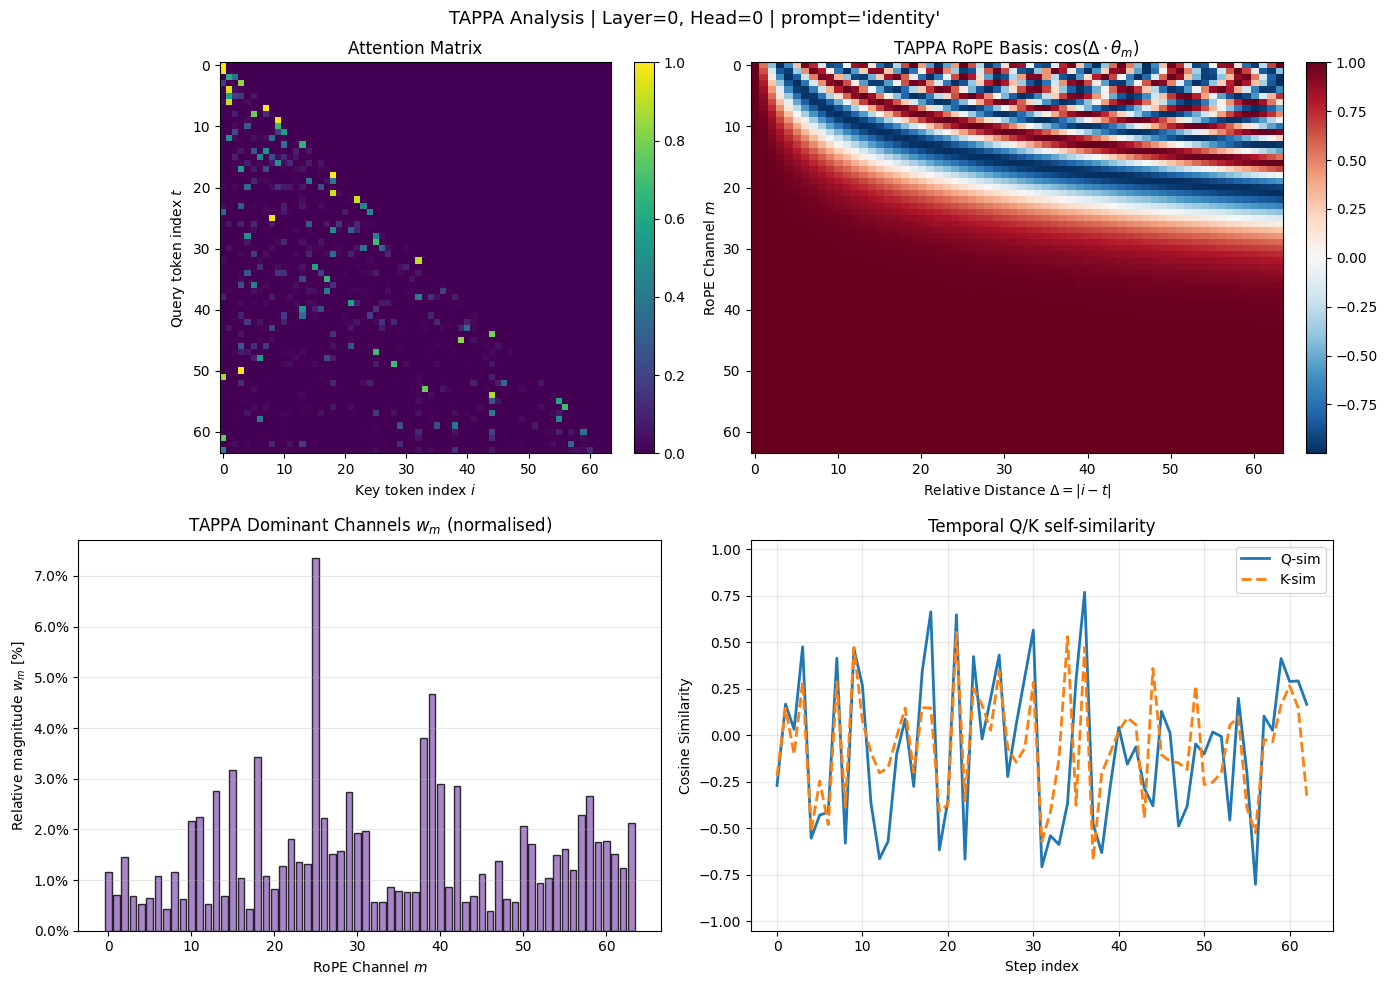

{'attention': array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.00000000e+00, 6.48498535e-05, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.41859055e-05, 6.21093750e-01, 3.76953125e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [7.53906250e-01, 2.60770321e-07, 2.11596489e-06, ...,
         7.56978989e-06, 0.00000000e+00, 0.00000000e+00],
        [1.10626221e-03, 1.61743164e-03, 3.46679688e-02, ...,
         1.49536133e-03, 3.81469727e-04, 0.00000000e+00],
        [4.21875000e-01, 5.31673431e-05, 2.70080566e-03, ...,
         7.01904297e-03, 7.82012939e-05, 2.16960907e-05]],
       shape=(64, 64), dtype=float32),
 'w_m': array([1.1651938 , 0.7124268 , 1.4575864 , 0.6841625 , 0.53361   ,
        0.6493188 , 1.0832602 , 0.43347082, 1.1515672 , 0.63160765,
        2.164248  , 2.239297  , 0.52332497, 2.7656415 , 0.6788797 ,
   

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal


def _temporal_cosine_sequence(x: torch.Tensor, eps: float = 1e-12) -> np.ndarray:
    """Return [cos(x_i, x_{i+1}) for i in 0..T-2] for x shape [T, d]."""
    if x.ndim != 2:
        raise ValueError("x must have shape [T, d]")
    if x.shape[0] < 2:
        return np.array([], dtype=np.float32)

    a = x[:-1].float()
    b = x[1:].float()
    numer = (a * b).sum(dim=-1)
    denom = a.norm(dim=-1) * b.norm(dim=-1)
    sims = numer / denom.clamp_min(eps)
    return sims.detach().cpu().numpy()


def _build_synthetic_embeddings(
    prompt_type: Literal["ones", "identity", "random"],
    seq_len: int,
    hidden_size: int,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    """
    Build a synthetic [1, seq_len, hidden_size] embedding tensor.

    Parameters
    ----------
    prompt_type : {"ones", "identity", "random"}
        - "ones"     : every token vector is the all-ones vector.
        - "identity" : token i is the i-th row of the (seq_len x hidden_size)
                       identity matrix, padded/truncated to hidden_size.
        - "random"   : token vectors sampled i.i.d. from N(0, 1).
    """
    if prompt_type == "ones":
        return torch.ones((1, seq_len, hidden_size), device=device, dtype=dtype)

    if prompt_type == "identity":
        eye = torch.zeros((seq_len, hidden_size), device=device, dtype=dtype)
        n = min(seq_len, hidden_size)
        eye[:n, :n] = torch.eye(n, device=device, dtype=dtype)
        return eye.unsqueeze(0)

    if prompt_type == "random":
        return torch.randn((1, seq_len, hidden_size), device=device, dtype=dtype)

    raise ValueError(f"Unknown prompt_type '{prompt_type}'. Choose 'ones', 'identity', or 'random'.")


def plot_attention_from_ones_prompt(
    model: torch.nn.Module,
    layer_idx: int,
    head_idx: int,
    seq_len: int = 64,
    dtype: torch.dtype | None = None,
    cmap: str = "viridis",
    prompt_type: Literal["ones", "identity", "random"] = "ones",
) -> dict[str, np.ndarray]:
    """
    Plot attention, RoPE basis, and TAPPA Dominant Channels for a synthetic prompt.

    Parameters
    ----------
    prompt_type : {"ones", "identity", "random"}
        Type of synthetic embedding used as input. See _build_synthetic_embeddings.
    """
    if seq_len <= 1:
        raise ValueError("seq_len must be >= 2")

    model.eval()
    device = next(model.parameters()).device

    embed_layer = model.get_input_embeddings()
    hidden_size = int(embed_layer.weight.shape[1])

    if dtype is None:
        p_dtype = next(model.parameters()).dtype
        dtype = p_dtype if p_dtype in (torch.float16, torch.bfloat16, torch.float32) else torch.float32

    # Architecture dims
    cfg = model.config
    num_heads = int(cfg.num_attention_heads)
    num_kv_heads = int(getattr(cfg, "num_key_value_heads", num_heads))
    head_dim = int(getattr(cfg, "head_dim", cfg.hidden_size // num_heads))
    group_size = num_heads // num_kv_heads
    kv_head_idx = head_idx // group_size
    M = head_dim // 2

    blocks = model.model.layers if hasattr(model, "model") else model.transformer.h
    attn_module = blocks[layer_idx].self_attn

    q_store: dict[str, torch.Tensor] = {}
    k_store: dict[str, torch.Tensor] = {}

    def q_hook(_module, _args, output): q_store["q"] = output.detach()
    def k_hook(_module, _args, output): k_store["k"] = output.detach()

    h_q = attn_module.q_proj.register_forward_hook(q_hook)
    h_k = attn_module.k_proj.register_forward_hook(k_hook)

    inputs_embeds = _build_synthetic_embeddings(prompt_type, seq_len, hidden_size, device, dtype)
    attention_mask = torch.ones((1, seq_len), device=device, dtype=torch.long)
    position_ids = torch.arange(seq_len, device=device).unsqueeze(0)

    with torch.no_grad():
        outputs = model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            position_ids=position_ids,
            output_attentions=True,
            use_cache=False,
        )

    h_q.remove()
    h_k.remove()

    t = int(outputs.attentions[layer_idx].shape[-1])
    attn = outputs.attentions[layer_idx][0, head_idx, :t, :t].detach().float().cpu().numpy()

    q_proj = q_store["q"][0, :t, :].float().view(t, num_heads, head_dim)
    k_proj = k_store["k"][0, :t, :].float().view(t, num_kv_heads, head_dim)

    q_head = q_proj[:, head_idx, :].contiguous()
    k_head = k_proj[:, kv_head_idx, :].contiguous()

    q_sim = _temporal_cosine_sequence(q_head)
    k_sim = _temporal_cosine_sequence(k_head)

    # =========================================================================
    # TAPPA: RoPE basis and Dominant Channels
    # =========================================================================
    rope_theta_base = float(getattr(cfg, "rope_theta", 10000.0))
    m_indices = np.arange(M)
    theta_m = rope_theta_base ** (-2.0 * m_indices / head_dim)

    delta = np.arange(t)
    rope_cos = np.cos(np.outer(theta_m, delta))  # [M, t]

    q_head_2d = q_head.view(t, M, 2)
    k_head_2d = k_head.view(t, M, 2)

    q_mag = torch.linalg.norm(q_head_2d, dim=-1)  # [t, M]
    k_mag = torch.linalg.norm(k_head_2d, dim=-1)  # [t, M]

    w_m_raw = (q_mag.mean(dim=0) * k_mag.mean(dim=0)).cpu().numpy()
    w_m_pct = 100.0 * w_m_raw / w_m_raw.sum()  # Normalised to percentage

    # =========================================================================
    # Visualization
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    fig.suptitle(f"TAPPA Analysis | Layer={layer_idx}, Head={head_idx} | prompt='{prompt_type}'", fontsize=13)

    # [0] Attention Matrix
    im0 = axes[0].imshow(attn, cmap=cmap, aspect="equal")
    axes[0].set_title("Attention Matrix")
    axes[0].set_xlabel("Key token index $i$")
    axes[0].set_ylabel("Query token index $t$")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # [1] RoPE Basis
    im1 = axes[1].imshow(rope_cos, cmap="RdBu_r", aspect="auto", origin="upper")
    axes[1].set_title("TAPPA RoPE Basis: $\\cos(\\Delta \\cdot \\theta_m)$")
    axes[1].set_xlabel("Relative Distance $\\Delta = |i - t|$")
    axes[1].set_ylabel("RoPE Channel $m$")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # [2] Dominant Channels (normalised %)
    axes[2].bar(m_indices, w_m_pct, color="tab:purple", alpha=0.8, edgecolor="black")
    axes[2].set_title("TAPPA Dominant Channels $w_m$ (normalised)")
    axes[2].set_xlabel("RoPE Channel $m$")
    axes[2].set_ylabel("Relative magnitude $w_m$ [%]")
    axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
    axes[2].grid(alpha=0.3, axis="y")

    # [3] Temporal Q/K similarity
    x = np.arange(len(q_sim))
    axes[3].plot(x, q_sim, label="Q-sim", color="tab:blue", linewidth=2)
    axes[3].plot(x, k_sim, label="K-sim", color="tab:orange", linewidth=2, linestyle="--")
    axes[3].set_title("Temporal Q/K self-similarity")
    axes[3].set_xlabel("Step index")
    axes[3].set_ylabel("Cosine Similarity")
    axes[3].set_ylim(-1.05, 1.05)
    axes[3].grid(alpha=0.3)
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    return {
        "attention": attn,
        "w_m": w_m_pct,
        "rope_cos": rope_cos,
        "q_sim": q_sim,
        "k_sim": k_sim,
    }

# Example usage:
plot_attention_from_ones_prompt(
    model=model,
    layer_idx=0,
    head_idx=0,
    seq_len=64,
    prompt_type="identity",
)   


/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_15827/3469696284.py:214: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_logits = plt.cm.get_cmap("RdBu_r").copy()


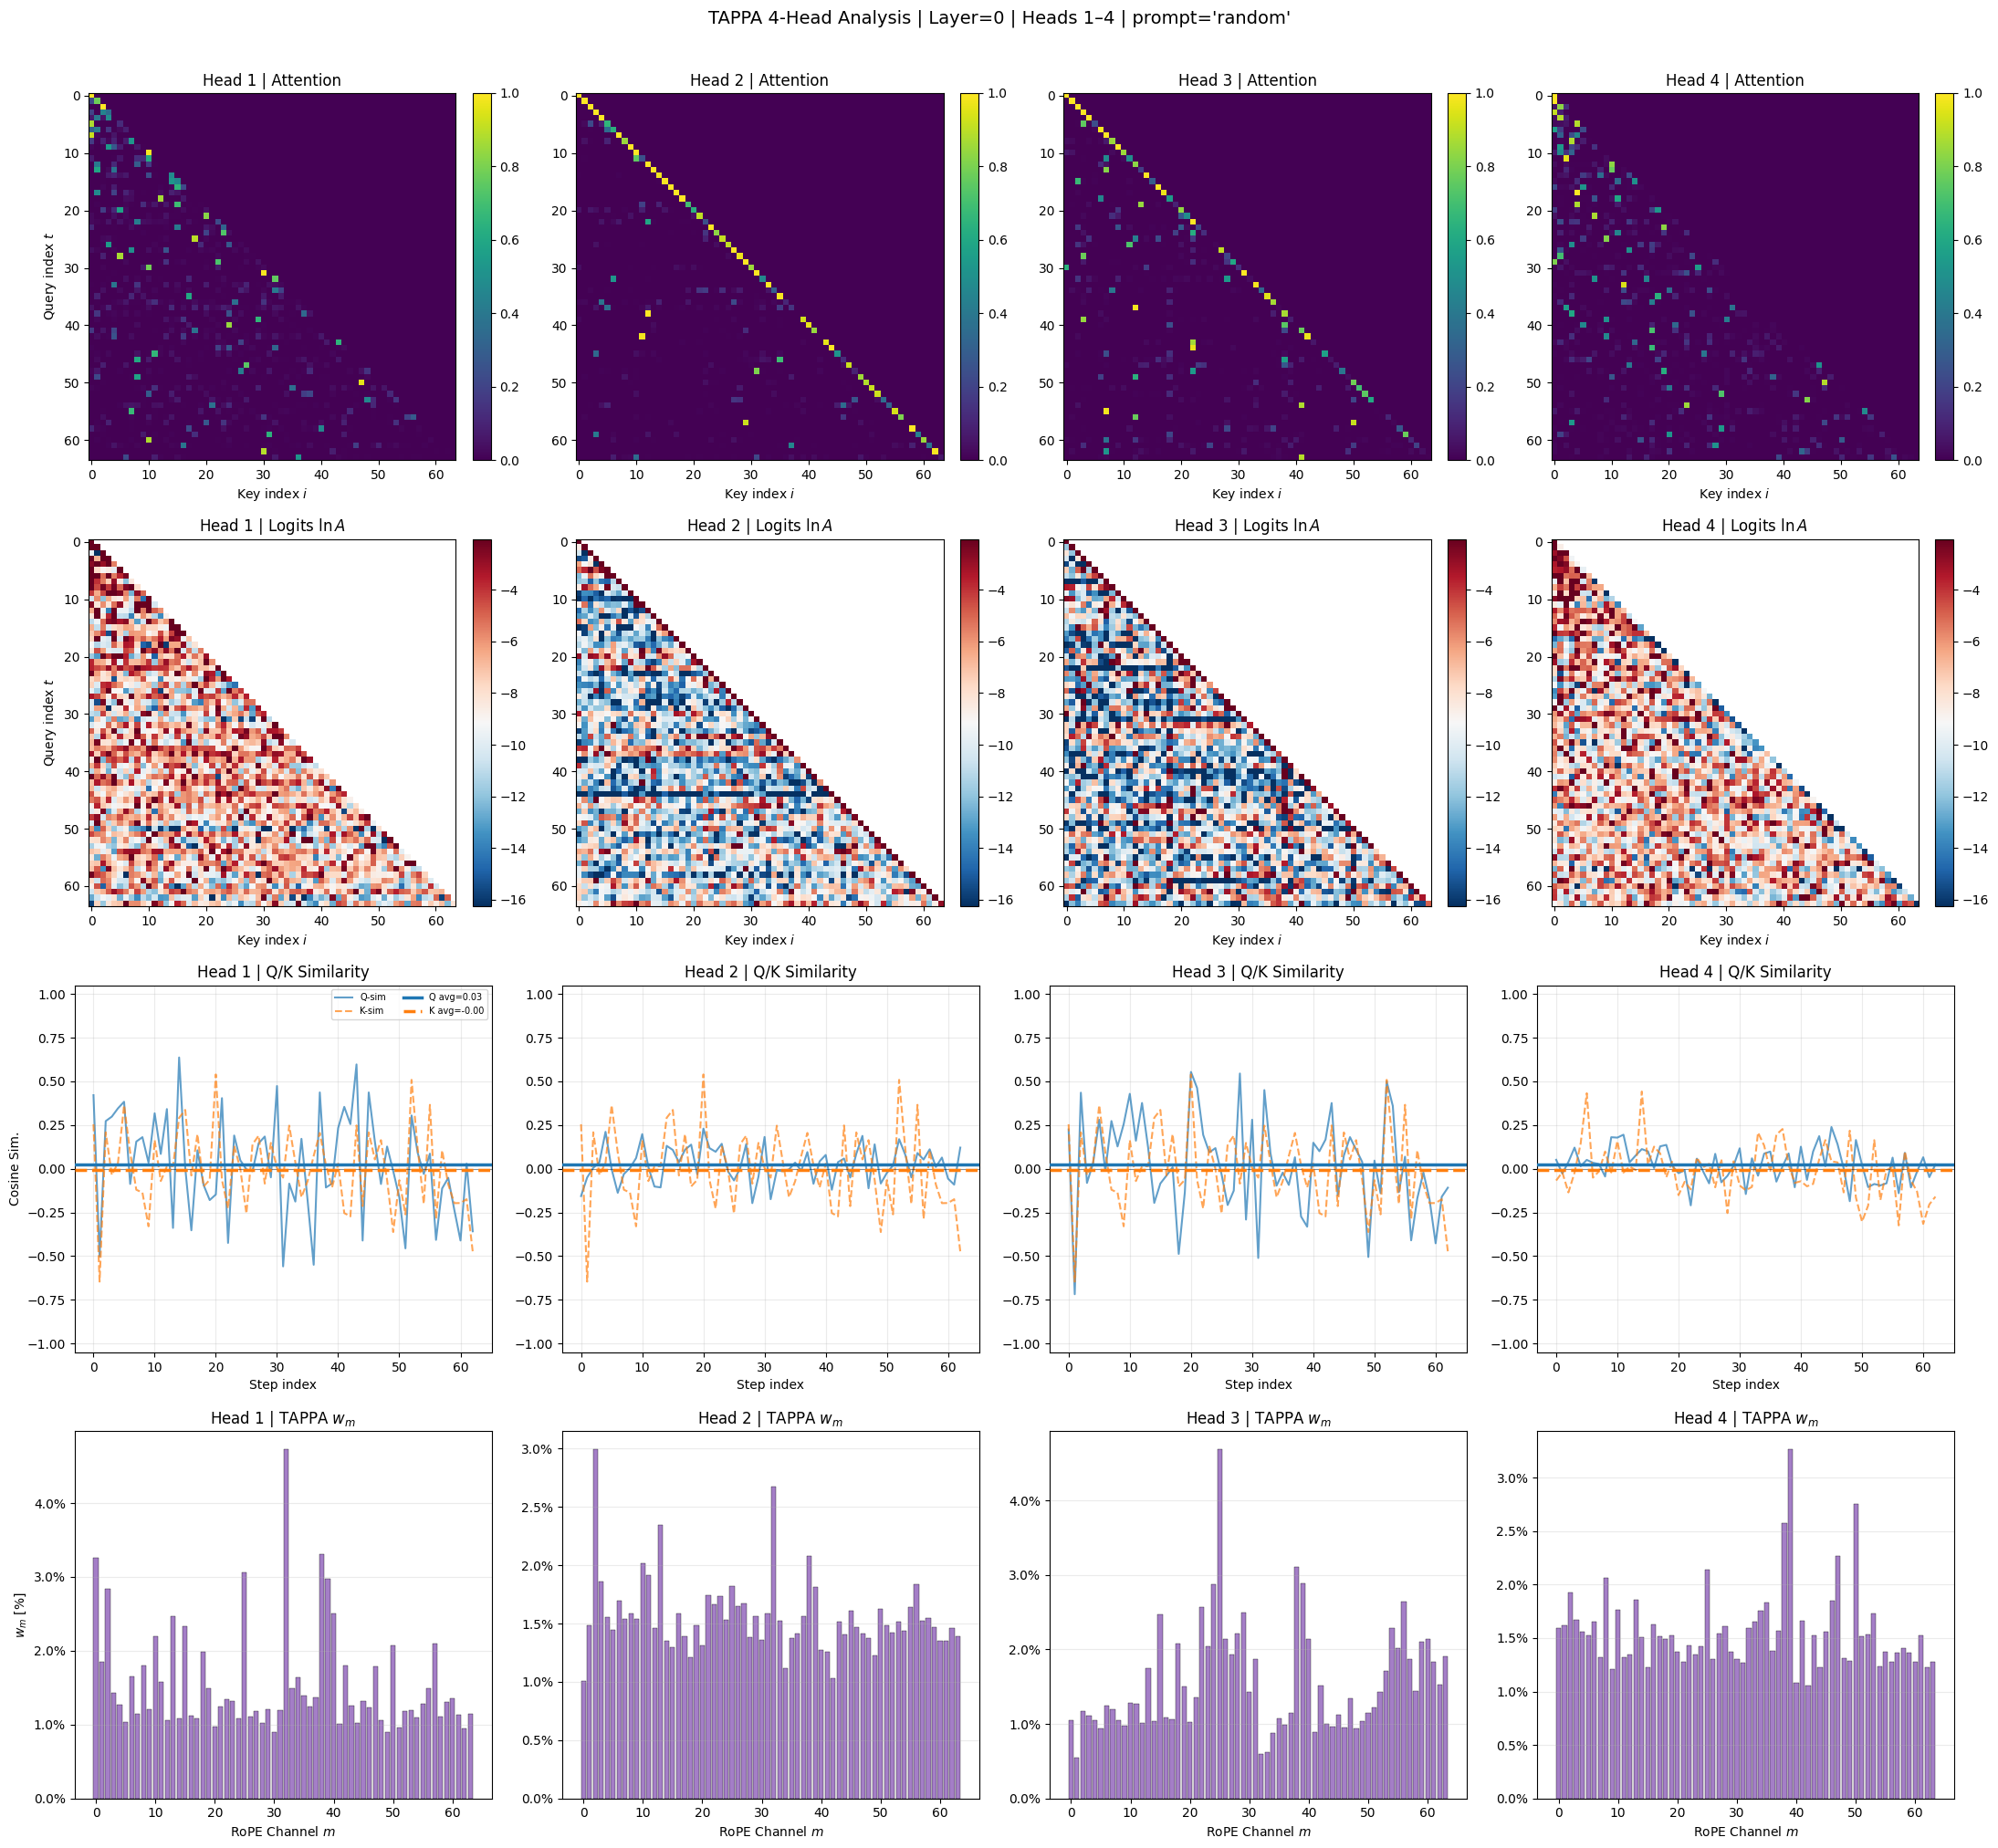

In [66]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal


def _temporal_cosine_sequence(x: torch.Tensor, eps: float = 1e-12) -> np.ndarray:
    """Return [cos(x_i, x_{i+1}) for i in 0..T-2] for x shape [T, d]."""
    if x.ndim != 2:
        raise ValueError("x must have shape [T, d]")
    if x.shape[0] < 2:
        return np.array([], dtype=np.float32)
    a = x[:-1].float()
    b = x[1:].float()
    numer = (a * b).sum(dim=-1)
    denom = a.norm(dim=-1) * b.norm(dim=-1)
    sims = numer / denom.clamp_min(eps)
    return sims.detach().cpu().numpy()


def _build_synthetic_embeddings(
    prompt_type: Literal["ones", "identity", "random", "half_rank_blocks"],
    seq_len: int,
    hidden_size: int,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    if prompt_type == "ones":
        return torch.ones((1, seq_len, hidden_size), device=device, dtype=dtype)
    if prompt_type == "identity":
        eye = torch.zeros((seq_len, hidden_size), device=device, dtype=dtype)
        n = min(seq_len, hidden_size)
        eye[:n, :n] = torch.eye(n, device=device, dtype=dtype)
        return eye.unsqueeze(0)
    if prompt_type == "random":
        return torch.randn((1, seq_len, hidden_size), device=device, dtype=dtype)
    if prompt_type == "half_rank_blocks":
        n_tokens_half = (seq_len + 1) // 2
        n_hidden_half = (hidden_size + 1) // 2
        r = min(n_tokens_half, n_hidden_half)
        eye_half = torch.zeros((n_tokens_half, n_hidden_half), device=device, dtype=dtype)
        eye_half[:r, :r] = torch.eye(r, device=device, dtype=dtype)
        full = torch.repeat_interleave(eye_half, repeats=2, dim=0)
        full = torch.repeat_interleave(full, repeats=2, dim=1)
        full = full[:seq_len, :hidden_size]
        return full.unsqueeze(0)
    if prompt_type == "chaos":
        # Log-normale base: sempre positivo, heavy-tailed, no cancellazione garantita
        x = torch.exp(torch.randn(seq_len, hidden_size) * 2.0)

        # Scaling per token su 4 ordini di grandezza (stessa logica di prima)
        token_scales = torch.pow(
            torch.tensor(10.0),
            torch.rand(seq_len, 1) * 4 - 2
        )
        x = x * token_scales

        # Spike positivi (no segno casuale — mantieni la positività)
        spike_mask = torch.rand_like(x) < 0.10
        spikes = torch.rand_like(x) * 1000   # solo positivi
        x = torch.where(spike_mask, spikes, x)

        x = x.clamp(1e-6, 1e4).to(device=device, dtype=dtype)
        return x.unsqueeze(0)


    raise ValueError(f"Unknown prompt_type '{prompt_type}'.")


def plot_four_heads_tappa(
    model: torch.nn.Module,
    layer_idx: int,
    first_head_idx: int,
    seq_len: int = 64,
    dtype: torch.dtype | None = None,
    cmap: str = "viridis",
    prompt_type: Literal["ones", "identity", "random", "half_rank_blocks", "chaos"] = "ones",
) -> dict[str, list]:
    """
    Run the model once and produce a 4x4 TAPPA analysis grid for four
    consecutive heads [first_head_idx, first_head_idx+3].

    Layout
    ------
    Row 0 : Attention matrix (post-softmax) for each of the 4 heads
    Row 1 : Pre-softmax logits (reconstructed via inverse softmax: ln(A))
            with causal mask applied (upper triangle = NaN)
    Row 2 : Temporal Q-sim / K-sim with global scalar averages
    Row 3 : TAPPA dominant channel weights w_m (%)
    """
    if seq_len <= 1:
        raise ValueError("seq_len must be >= 2")

    model.eval()
    device = next(model.parameters()).device
    embed_layer = model.get_input_embeddings()
    hidden_size = int(embed_layer.weight.shape[1])

    if dtype is None:
        p_dtype = next(model.parameters()).dtype
        dtype = p_dtype if p_dtype in (torch.float16, torch.bfloat16, torch.float32) else torch.float32

    cfg          = model.config
    num_heads    = int(cfg.num_attention_heads)
    num_kv_heads = int(getattr(cfg, "num_key_value_heads", num_heads))
    head_dim     = int(getattr(cfg, "head_dim", cfg.hidden_size // num_heads))
    group_size   = num_heads // num_kv_heads
    M            = head_dim // 2

    n_heads_to_plot = 4
    head_indices = [first_head_idx + i for i in range(n_heads_to_plot)]
    assert all(h < num_heads for h in head_indices), \
        f"head index out of range (model has {num_heads} heads)"

    # Single forward pass
    blocks      = model.model.layers if hasattr(model, "model") else model.transformer.h
    attn_module = blocks[layer_idx].self_attn

    q_store: dict[str, torch.Tensor] = {}
    k_store: dict[str, torch.Tensor] = {}

    def q_hook(_m, _a, output): q_store["q"] = output.detach()
    def k_hook(_m, _a, output): k_store["k"] = output.detach()

    h_q = attn_module.q_proj.register_forward_hook(q_hook)
    h_k = attn_module.k_proj.register_forward_hook(k_hook)

    inputs_embeds  = _build_synthetic_embeddings(prompt_type, seq_len, hidden_size, device, dtype)
    attention_mask = torch.ones((1, seq_len), device=device, dtype=torch.long)
    position_ids   = torch.arange(seq_len, device=device).unsqueeze(0)

    with torch.no_grad():
        outputs = model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            position_ids=position_ids,
            output_attentions=True,
            use_cache=False,
        )

    h_q.remove()
    h_k.remove()

    t = int(outputs.attentions[layer_idx].shape[-1])

    q_proj_full = q_store["q"][0, :t, :].float().view(t, num_heads, head_dim)
    k_proj_full = k_store["k"][0, :t, :].float().view(t, num_kv_heads, head_dim)

    rope_theta_base = float(getattr(cfg, "rope_theta", 10000.0))
    m_indices = np.arange(M)
    theta_m   = rope_theta_base ** (-2.0 * m_indices / head_dim)
    delta     = np.arange(t)
    rope_cos  = np.cos(np.outer(theta_m, delta))  # [M, t]

    # Causal mask for logit visualization: upper triangle → NaN
    causal_mask = np.triu(np.ones((t, t), dtype=bool), k=1)

    # =========================================================================
    # Per-head data extraction
    # =========================================================================
    attn_matrices  = []
    logit_matrices = []
    q_sims, k_sims = [], []
    w_m_pcts       = []

    for head_idx in head_indices:
        kv_head_idx = head_idx // group_size

        # Attention weights (post-softmax)
        attn = outputs.attentions[layer_idx][0, head_idx, :t, :t].detach().float().cpu().numpy()
        attn_matrices.append(attn)

        # Reconstruct pre-softmax logits via inverse softmax: logit ≈ ln(A) + const(row)
        # The row-wise constant does not affect the visual structure.
        attn_safe = np.clip(attn, a_min=1e-12, a_max=1.0)
        logits    = np.log(attn_safe)
        logits[causal_mask] = np.nan   # Mask future tokens
        logit_matrices.append(logits)

        q_head = q_proj_full[:, head_idx,    :].contiguous()
        k_head = k_proj_full[:, kv_head_idx, :].contiguous()

        q_sims.append(_temporal_cosine_sequence(q_head))
        k_sims.append(_temporal_cosine_sequence(k_head))

        q_head_2d = q_head.view(t, M, 2)
        k_head_2d = k_head.view(t, M, 2)
        q_mag     = torch.linalg.norm(q_head_2d, dim=-1)
        k_mag     = torch.linalg.norm(k_head_2d, dim=-1)
        w_raw     = (q_mag.mean(0) * k_mag.mean(0)).cpu().numpy()
        w_m_pcts.append(100.0 * w_raw / w_raw.sum())

    q_avg = float(np.mean(np.stack(q_sims, axis=0)))
    k_avg = float(np.mean(np.stack(k_sims, axis=0)))

    # =========================================================================
    # Visualization — 4 rows x 4 columns
    # =========================================================================
    fig, axes = plt.subplots(4, 4, figsize=(22, 20))
    fig.suptitle(
        f"TAPPA 4-Head Analysis | Layer={layer_idx} | "
        f"Heads {head_indices[0]}–{head_indices[-1]} | prompt='{prompt_type}'",
        fontsize=14, y=1.01
    )

    step_x = np.arange(t - 1)

    # Shared color range for logits: use the 5th–95th percentile across all heads
    # to prevent a single outlier cell from compressing the colorscale
    all_logits_valid = np.concatenate([l[~np.isnan(l)].ravel() for l in logit_matrices])
    logit_vmin = float(np.percentile(all_logits_valid, 5))
    logit_vmax = float(np.percentile(all_logits_valid, 95))

    cmap_logits = plt.cm.get_cmap("RdBu_r").copy()
    cmap_logits.set_bad(color="white")

    for col, head_idx in enumerate(head_indices):

        # ── Row 0: Attention Matrix (post-softmax) ───────────────────────────
        ax0 = axes[0, col]
        im0 = ax0.imshow(attn_matrices[col], cmap=cmap, aspect="equal")
        ax0.set_title(f"Head {head_idx} | Attention")
        ax0.set_xlabel("Key index $i$")
        ax0.set_ylabel("Query index $t$" if col == 0 else "")
        plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

        # ── Row 1: Pre-Softmax Logits (inverse softmax, causal mask) ─────────
        ax1 = axes[1, col]
        im1 = ax1.imshow(
            logit_matrices[col], cmap=cmap_logits, aspect="equal",
            vmin=logit_vmin, vmax=logit_vmax
        )
        ax1.set_title(f"Head {head_idx} | Logits $\\ln A$")
        ax1.set_xlabel("Key index $i$")
        ax1.set_ylabel("Query index $t$" if col == 0 else "")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # ── Row 2: Temporal Q/K Similarities ─────────────────────────────────
        ax2 = axes[2, col]
        ax2.plot(step_x, q_sims[col], color="tab:blue",  lw=1.5, alpha=0.7, label="Q-sim")
        ax2.plot(step_x, k_sims[col], color="tab:orange", lw=1.5, alpha=0.7, label="K-sim", ls="--")
        ax2.axhline(q_avg, color="tab:blue",  lw=2.5, ls="-",  zorder=3, label=f"Q avg={q_avg:.2f}")
        ax2.axhline(k_avg, color="tab:orange", lw=2.5, ls="--", zorder=3, label=f"K avg={k_avg:.2f}")
        ax2.axhline(0, color="black", lw=0.8, alpha=0.4)
        ax2.set_title(f"Head {head_idx} | Q/K Similarity")
        ax2.set_xlabel("Step index")
        ax2.set_ylabel("Cosine Sim." if col == 0 else "")
        ax2.set_ylim(-1.05, 1.05)
        ax2.grid(alpha=0.25)
        if col == 0:
            ax2.legend(fontsize=7, ncol=2)

        # ── Row 3: TAPPA Dominant Channels ────────────────────────────────────
        ax3 = axes[3, col]
        ax3.bar(m_indices, w_m_pcts[col], color="tab:purple", alpha=0.85, edgecolor="black", lw=0.3)
        ax3.set_title(f"Head {head_idx} | TAPPA $w_m$")
        ax3.set_xlabel("RoPE Channel $m$")
        ax3.set_ylabel("$w_m$ [%]" if col == 0 else "")
        ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
        ax3.grid(alpha=0.25, axis="y")

    plt.tight_layout()
    plt.show()

    return {
        "attention_matrices":  attn_matrices,
        "logit_matrices":      logit_matrices,
        "q_sims":              q_sims,
        "k_sims":              k_sims,
        "q_avg":               q_avg,
        "k_avg":               k_avg,
        "w_m_pcts":            w_m_pcts,
        "rope_cos":            rope_cos,
        # ── Aggiunte necessarie ──
        "q_proj_full":         q_proj_full,   # [t, num_heads, head_dim]
        "k_proj_full":         k_proj_full,   # [t, num_kv_heads, head_dim]
    }

# Example usage:
results = plot_four_heads_tappa(
    model=model,
    layer_idx=0,
    first_head_idx=1,
    seq_len=64,
    prompt_type="random",
)


  Head |   E_diag emp   E_diag thr |  E_offdiag emp  E_offdiag thr |   Var_diag emp   Var_diag thr |  Var_off emp  Var_off thr
     0 |       0.0011      -0.0004 |        -0.0001         0.0000 |         0.0000         0.0000 |       0.0000       0.0000
     1 |       0.0009      -0.0002 |         0.0000         0.0000 |         0.0000         0.0000 |       0.0000       0.0000
     2 |       0.0029       0.0013 |         0.0000         0.0000 |         0.0000         0.0000 |       0.0000       0.0000
     3 |       0.0032       0.0010 |        -0.0000         0.0000 |         0.0000         0.0000 |       0.0000       0.0000



/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_15827/1073325452.py:154: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_l = plt.cm.get_cmap("RdBu_r").copy()


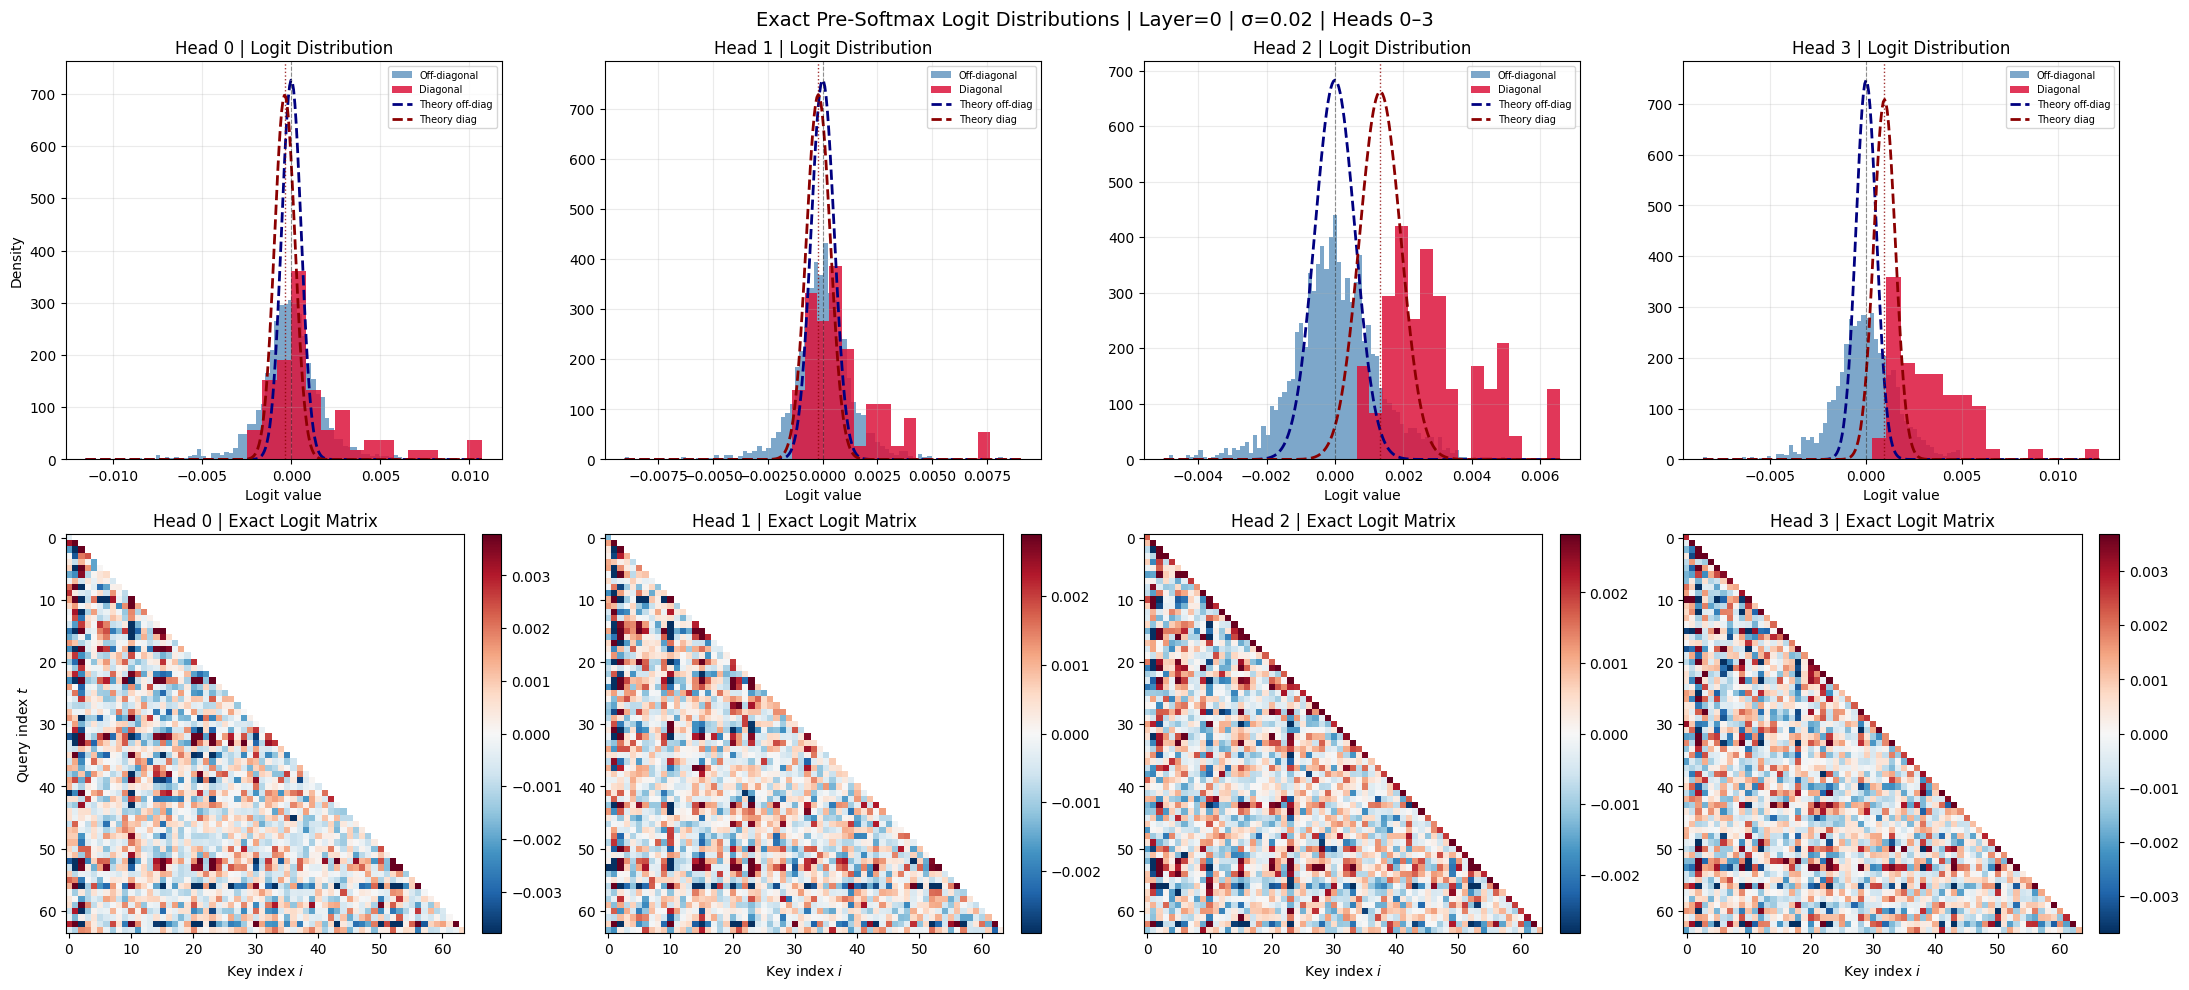

In [67]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import stats as scipy_stats


@torch.inference_mode()
def plot_logit_distributions_from_tappa(
    model,
    tappa_outputs: dict,
    layer_idx: int,
    head_indices: list[int],
    sigma: float = 1.0,
    n_bins: int = 80,
) -> None:
    """
    Given the raw Q/K projections captured during plot_four_heads_tappa,
    compute the EXACT pre-softmax logit matrix (post-RoPE, no softmax shift)
    and plot:
      1. Distribution of diagonal vs off-diagonal logit values per head
      2. Empirical vs theoretical mean and variance

    Parameters
    ----------
    tappa_outputs : dict returned by plot_four_heads_tappa (must contain
                    raw q_proj_full and k_proj_full — see note below)
    sigma         : std of input embeddings (1.0 for 'random' prompt_type)
    """
    cfg          = model.config
    num_heads    = int(cfg.num_attention_heads)
    num_kv_heads = int(getattr(cfg, "num_key_value_heads", num_heads))
    head_dim     = int(getattr(cfg, "head_dim", cfg.hidden_size // num_heads))
    group_size   = num_heads // num_kv_heads

    # =========================================================================
    # Retrieve Q and K projections from tappa_outputs
    # =========================================================================
    q_proj_full = tappa_outputs["q_proj_full"]   # [t, num_heads, head_dim]
    k_proj_full = tappa_outputs["k_proj_full"]   # [t, num_kv_heads, head_dim]
    t = q_proj_full.shape[0]

    # =========================================================================
    # Compute theoretical values from weight matrices
    # W_Q^(h) @ W_K^(h)^T = A  (folded, [d_model, d_model])
    # For X ~ N(0, sigma^2 I): E[C_ii] = sigma^2 * Tr(A)
    # =========================================================================
    blocks      = model.model.layers if hasattr(model, "model") else model.transformer.h
    attn_module = blocks[layer_idx].self_attn

    W_q_full = attn_module.q_proj.weight.detach().float()   # [num_heads*head_dim, d_model]
    W_k_full = attn_module.k_proj.weight.detach().float()   # [num_kv_heads*head_dim, d_model]

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle(
        f"Exact Pre-Softmax Logit Distributions | Layer={layer_idx} | "
        f"σ={sigma} | Heads {head_indices[0]}–{head_indices[-1]}",
        fontsize=14
    )

    print(f"\n{'':=<100}")
    print(f"{'Head':>6} | {'E_diag emp':>12} {'E_diag thr':>12} | "
          f"{'E_offdiag emp':>14} {'E_offdiag thr':>14} | "
          f"{'Var_diag emp':>14} {'Var_diag thr':>14} | "
          f"{'Var_off emp':>12} {'Var_off thr':>12}")
    print(f"{'':=<100}")

    for col, head_idx in enumerate(head_indices):
        kv_head_idx = head_idx // group_size

        # ── Exact logit matrix: Q @ K^T / sqrt(d_h) ─────────────────────────
        q_head = q_proj_full[:, head_idx,    :].float()  # [t, head_dim]
        k_head = k_proj_full[:, kv_head_idx, :].float()  # [t, head_dim]

        logits_exact = (q_head @ k_head.T) / math.sqrt(head_dim)  # [t, t]
        logits_np    = logits_exact.cpu().numpy()

        # Apply causal mask (set upper triangle to NaN for bookkeeping,
        # but compute stats ONLY on valid lower-triangular elements)
        diag_vals    = np.diag(logits_np)
        tril_mask    = np.tril(np.ones((t, t), dtype=bool), k=-1)
        offdiag_vals = logits_np[tril_mask]

        # ── Empirical statistics ─────────────────────────────────────────────
        emp_mean_diag    = float(diag_vals.mean())
        emp_mean_offdiag = float(offdiag_vals.mean())
        emp_var_diag     = float(diag_vals.var())
        emp_var_offdiag  = float(offdiag_vals.var())

        # ── Theoretical statistics ───────────────────────────────────────────
        # Extract head-wise weight slices: [head_dim, d_model]
        W_Q_h = W_q_full.view(num_heads,  head_dim, -1)[head_idx]    # [head_dim, d_model]
        W_K_h = W_k_full.view(num_kv_heads, head_dim, -1)[kv_head_idx]  # [head_dim, d_model]

        # A = (1/sqrt(d_h)) * W_Q^T W_K  shape [d_model, d_model]
        # (accounting for the 1/sqrt(d_h) scaling of logits)
        A = (W_Q_h.T @ W_K_h) / math.sqrt(head_dim)   # [d_model, d_model]

        # Theoretical mean on diagonal: sigma^2 * Tr(A)
        thr_mean_diag    = float(sigma ** 2 * torch.trace(A).item())
        thr_mean_offdiag = 0.0

        # Theoretical variance uses ||A||_F^2 and Tr(A^2)
        A_frob_sq  = float(torch.norm(A, p='fro').item() ** 2)
        # Tr(A^T A) = ||A||_F^2 for any A
        # Tr(A^2) for the symmetric part
        trA2       = float(torch.trace(A @ A).item())

        # Var(C_ii) = sigma^4 * (||A||_F^2 + Tr(A^2))
        thr_var_diag    = float(sigma ** 4 * (A_frob_sq + trA2))
        # Var(C_ij) i!=j = sigma^4 * ||A||_F^2
        thr_var_offdiag = float(sigma ** 4 * A_frob_sq)

        # ── Print table row ───────────────────────────────────────────────────
        print(f"{head_idx:>6} | {emp_mean_diag:>12.4f} {thr_mean_diag:>12.4f} | "
              f"{emp_mean_offdiag:>14.4f} {thr_mean_offdiag:>14.4f} | "
              f"{emp_var_diag:>14.4f} {thr_var_diag:>14.4f} | "
              f"{emp_var_offdiag:>12.4f} {thr_var_offdiag:>12.4f}")

        # ── Row 0: Logit distribution histogram ──────────────────────────────
        ax0 = axes[0, col]
        ax0.hist(offdiag_vals, bins=n_bins, density=True,
                 color="steelblue", alpha=0.7, label="Off-diagonal")
        ax0.hist(diag_vals,    bins=max(10, t // 4), density=True,
                 color="crimson",   alpha=0.85, label="Diagonal")

        # Overlay theoretical Gaussians
        x_range = np.linspace(logits_np[~np.isnan(logits_np)].min(),
                              logits_np[~np.isnan(logits_np)].max(), 300)
        if thr_var_offdiag > 0:
            ax0.plot(x_range,
                     scipy_stats.norm.pdf(x_range, thr_mean_offdiag,
                                          math.sqrt(thr_var_offdiag)),
                     color="navy", lw=2, ls="--", label="Theory off-diag")
        if thr_var_diag > 0:
            ax0.plot(x_range,
                     scipy_stats.norm.pdf(x_range, thr_mean_diag,
                                          math.sqrt(thr_var_diag)),
                     color="darkred", lw=2, ls="--", label="Theory diag")

        ax0.axvline(thr_mean_diag, color="darkred", lw=1.0, ls=":", alpha=0.8)
        ax0.axvline(0, color="black", lw=0.8, ls="--", alpha=0.4)
        ax0.set_title(f"Head {head_idx} | Logit Distribution")
        ax0.set_xlabel("Logit value")
        ax0.set_ylabel("Density" if col == 0 else "")
        ax0.legend(fontsize=7)
        ax0.grid(alpha=0.25)

        # ── Row 1: Exact logit matrix heatmap ────────────────────────────────
        ax1 = axes[1, col]
        logits_masked = logits_np.copy()
        logits_masked[np.triu(np.ones((t, t), dtype=bool), k=1)] = np.nan

        cmap_l = plt.cm.get_cmap("RdBu_r").copy()
        cmap_l.set_bad("white")
        vmax = float(np.nanpercentile(np.abs(logits_masked), 95))
        im1 = ax1.imshow(logits_masked, cmap=cmap_l, aspect="equal",
                         vmin=-vmax, vmax=vmax)
        ax1.set_title(f"Head {head_idx} | Exact Logit Matrix")
        ax1.set_xlabel("Key index $i$")
        ax1.set_ylabel("Query index $t$" if col == 0 else "")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    print(f"{'':=<100}\n")
    plt.tight_layout()
    plt.show()


plot_logit_distributions_from_tappa(
    model=model,
    tappa_outputs=results,
    layer_idx=0,
    head_indices=[0, 1, 2, 3],
    sigma=0.02,   # std di torch.randn
)


/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_15827/384806766.py:84: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result_ad = scipy_stats.anderson(emb)
/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_15827/384806766.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp

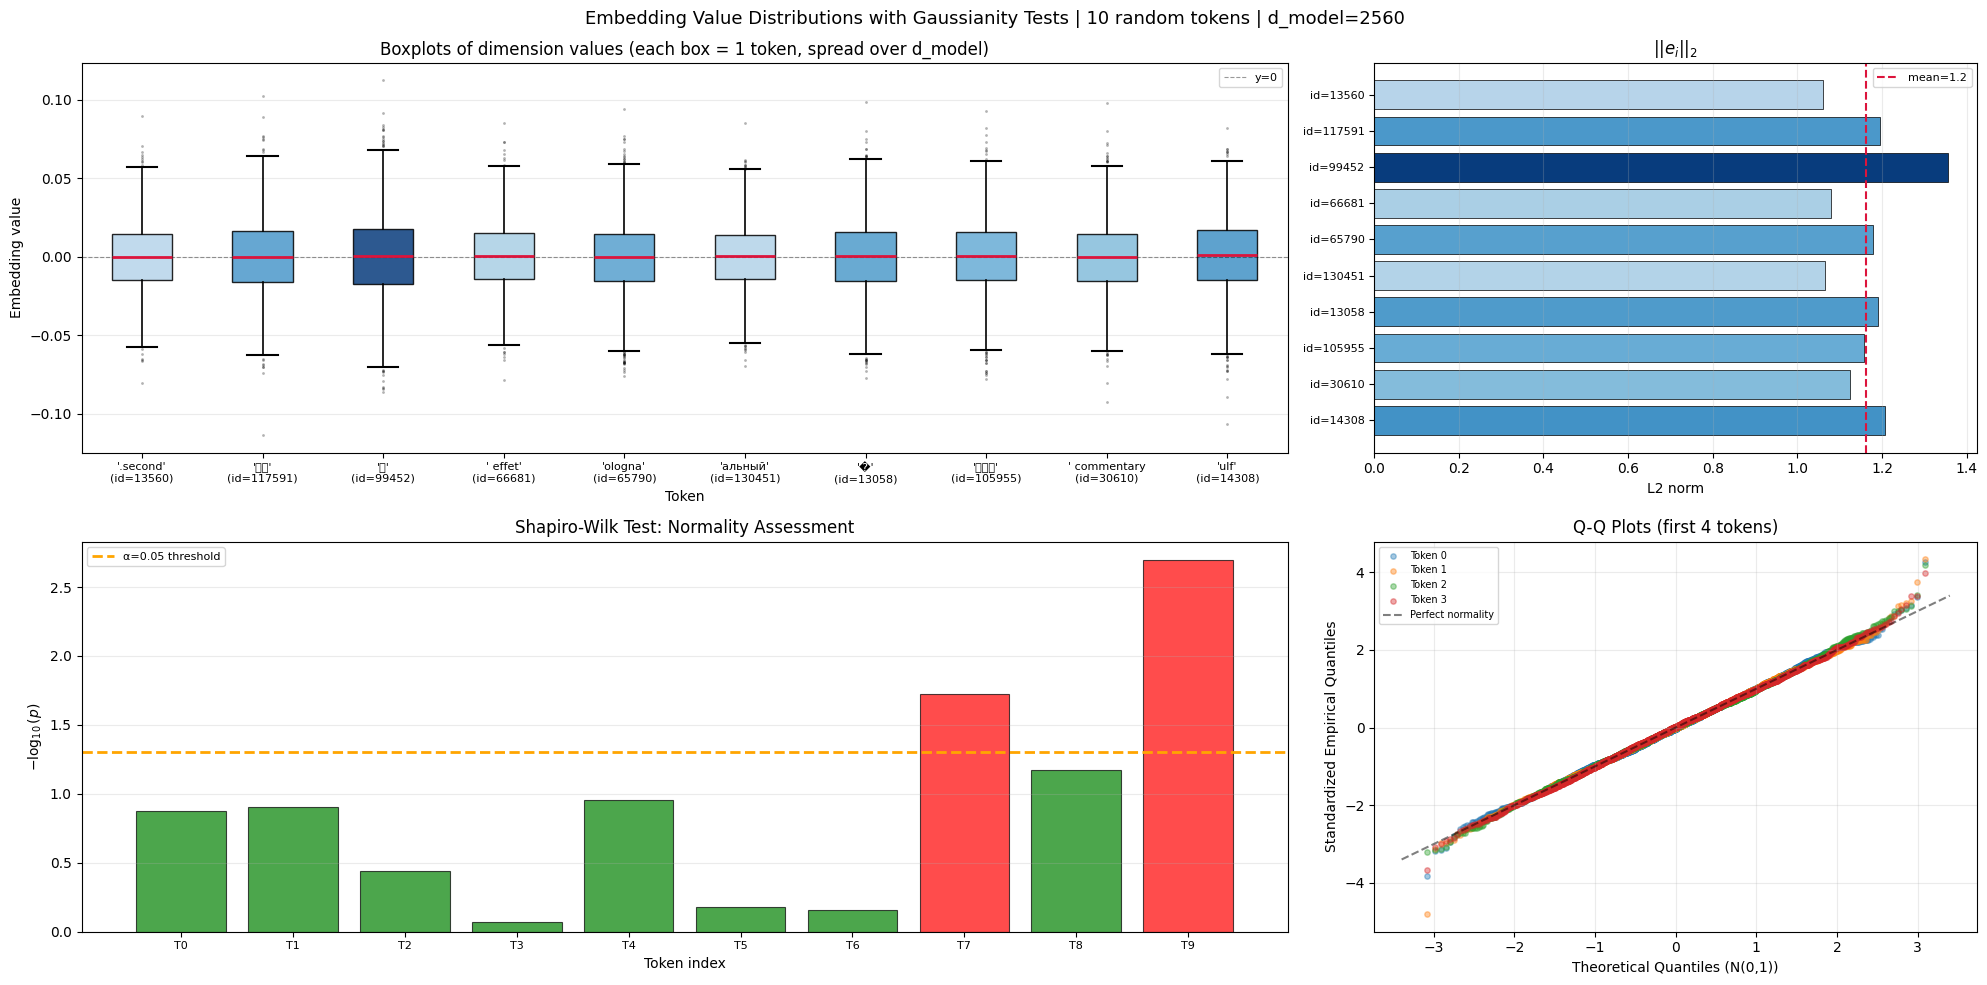


Token                id    ||e||_2       mean        std   SW p-val   A-D stat
--------------------------------------------------------------------------------------------
'.second'         13560      1.060     0.0002     0.0210   1.32e-01      0.698
'颈部'             117591      1.196     0.0002     0.0236   1.24e-01      0.173
'招'               99452      1.357     0.0003     0.0268   3.64e-01      0.383
' effet'          66681      1.078     0.0004     0.0213   8.51e-01      0.311
'ologna'          65790      1.179    -0.0000     0.0233   1.10e-01      0.696
'альный'         130451      1.065    -0.0001     0.0210   6.62e-01      0.275
'�'               13058      1.190     0.0002     0.0235   6.90e-01      0.333
'不愿意'            105955      1.156     0.0007     0.0228   1.88e-02      0.801
' commentary      30610      1.123    -0.0001     0.0222   6.67e-02      0.558
'ulf'             14308      1.207     0.0007     0.0238   2.02e-03      0.766

Interpretation Guide:
  - Shapiro-Wi

In [68]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats


@torch.inference_mode()
def plot_embedding_distributions(
    model,
    tokenizer,
    n_tokens: int = 10,
    seed: int = 42,
    figsize: tuple = (20, 10),
) -> dict:
    """
    Sample n_tokens random token ids from the vocabulary, extract their
    embedding vectors, and plot side-by-side boxplots of the raw dimension
    values for each token. Also performs Gaussianity tests.

    Each boxplot shows the distribution of the 2560 (or d_model) scalar
    values of that token's embedding vector — i.e., the spread across
    the hidden dimension, NOT across tokens.
    
    Statistical Tests (per token):
      - Shapiro-Wilk:      Tests if distribution is normal (p > 0.05 suggests normal)
      - Anderson-Darling:  More sensitive to distribution tails
      - Jarque-Bera:       Omnibus test based on skewness and kurtosis
    """
    model.eval()
    device = next(model.parameters()).device

    embed_matrix = model.get_input_embeddings().weight.detach().float().cpu()
    vocab_size, d_model = embed_matrix.shape

    rng = np.random.default_rng(seed)
    token_ids = rng.integers(0, vocab_size, size=n_tokens, dtype=np.int64).tolist()

    # Extract embedding vectors: shape [n_tokens, d_model]
    embeddings = embed_matrix[token_ids].numpy()

    # Decode token strings for labels (fallback to id if decoding fails)
    labels = []
    for tid in token_ids:
        try:
            tok_str = tokenizer.decode([tid], skip_special_tokens=False)
            tok_str = repr(tok_str)[:12]  # Truncate long strings
        except Exception:
            tok_str = f"id={tid}"
        labels.append(f"{tok_str}\n(id={tid})")

    # =========================================================================
    # Compute summary statistics and Gaussian compatibility tests
    # =========================================================================
    stats = {
        "token_ids":  token_ids,
        "norms":      np.linalg.norm(embeddings, axis=1),
        "means":      embeddings.mean(axis=1),
        "stds":       embeddings.std(axis=1),
        "medians":    np.median(embeddings, axis=1),
        "skewness":   scipy_stats.skew(embeddings, axis=1),
        "kurtosis":   scipy_stats.kurtosis(embeddings, axis=1),
        "shapiro_stat":     np.zeros(n_tokens),
        "shapiro_pval":     np.zeros(n_tokens),
        "anderson_stat":    np.zeros(n_tokens),
        "jarque_bera_stat": np.zeros(n_tokens),
        "jarque_bera_pval": np.zeros(n_tokens),
    }

    # Perform Gaussian compatibility tests for each token
    for i, emb in enumerate(embeddings):
        # Shapiro-Wilk test (works best for n < 5000)
        if len(emb) <= 5000:
            stat_sw, pval_sw = scipy_stats.shapiro(emb)
            stats["shapiro_stat"][i] = stat_sw
            stats["shapiro_pval"][i] = pval_sw
        else:
            # For large samples, use a subsample
            subsample = rng.choice(emb, size=5000, replace=False)
            stat_sw, pval_sw = scipy_stats.shapiro(subsample)
            stats["shapiro_stat"][i] = stat_sw
            stats["shapiro_pval"][i] = pval_sw

        # Anderson-Darling test
        result_ad = scipy_stats.anderson(emb)
        stats["anderson_stat"][i] = result_ad.statistic

        # Jarque-Bera test
        stat_jb, pval_jb = scipy_stats.jarque_bera(emb)
        stats["jarque_bera_stat"][i] = stat_jb
        stats["jarque_bera_pval"][i] = pval_jb

    # =========================================================================
    # Visualization
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=figsize,
                             gridspec_kw={"width_ratios": [2, 1], "height_ratios": [1, 1]})
    fig.suptitle(
        f"Embedding Value Distributions with Gaussianity Tests | {n_tokens} random tokens | d_model={d_model}",
        fontsize=13
    )

    # ── Top-Left: Boxplots (one per token, across d_model dimensions) ────────
    ax0 = axes[0, 0]
    bp = ax0.boxplot(
        embeddings.T,                   # shape [d_model, n_tokens] — one column per token
        labels=labels,
        patch_artist=True,
        notch=False,
        vert=True,
        showfliers=True,
        flierprops=dict(marker=".", markersize=2, alpha=0.3, color="gray"),
        medianprops=dict(color="crimson", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
    )

    # Color each box by L2 norm (higher norm → darker blue)
    norm_vals = stats["norms"]
    norm_min, norm_max = norm_vals.min(), norm_vals.max()
    cmap_boxes = plt.cm.Blues
    for i, (patch, norm_val) in enumerate(zip(bp["boxes"], norm_vals)):
        intensity = 0.3 + 0.65 * (norm_val - norm_min) / (norm_max - norm_min + 1e-12)
        patch.set_facecolor(cmap_boxes(intensity))
        patch.set_alpha(0.85)

    ax0.axhline(0, color="black", lw=0.8, ls="--", alpha=0.4, label="y=0")
    ax0.set_title("Boxplots of dimension values (each box = 1 token, spread over d_model)")
    ax0.set_ylabel("Embedding value")
    ax0.set_xlabel("Token")
    ax0.tick_params(axis="x", labelsize=8)
    ax0.grid(alpha=0.25, axis="y")
    ax0.legend(fontsize=8)

    # ── Top-Right: L2 norm per token (horizontal bar) ──────────────────────
    ax1 = axes[0, 1]
    colors = [cmap_boxes(0.3 + 0.65 * (v - norm_min) / (norm_max - norm_min + 1e-12))
              for v in norm_vals]
    short_labels = [f"id={tid}" for tid in token_ids]

    ax1.barh(np.arange(n_tokens), norm_vals[::-1], color=colors[::-1],
             edgecolor="black", linewidth=0.5)
    ax1.set_yticks(np.arange(n_tokens))
    ax1.set_yticklabels(short_labels[::-1], fontsize=8)
    ax1.set_title("$||e_i||_2$")
    ax1.set_xlabel("L2 norm")
    ax1.axvline(norm_vals.mean(), color="crimson", lw=1.5, ls="--",
                label=f"mean={norm_vals.mean():.1f}")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.25, axis="x")

    # ── Bottom-Left: Shapiro-Wilk p-values ───────────────────────────────────
    ax2 = axes[1, 0]
    colors_sw = np.where(stats["shapiro_pval"] > 0.05, "green", "red")
    bars2 = ax2.bar(range(n_tokens), -np.log10(stats["shapiro_pval"]), 
                    color=colors_sw, alpha=0.7, edgecolor="black", linewidth=0.8)
    ax2.axhline(-np.log10(0.05), color="orange", lw=2, ls="--", 
                label="α=0.05 threshold")
    ax2.set_ylabel("$-\\log_{10}(p)$")
    ax2.set_xlabel("Token index")
    ax2.set_title("Shapiro-Wilk Test: Normality Assessment")
    ax2.set_xticks(range(n_tokens))
    ax2.set_xticklabels([f"T{i}" for i in range(n_tokens)], fontsize=8)
    ax2.grid(alpha=0.25, axis="y")
    ax2.legend(fontsize=8)

    # ── Bottom-Right: Q-Q plots (first 4 tokens) ──────────────────────────────
    ax3 = axes[1, 1]
    n_qq = min(4, n_tokens)
    for idx in range(n_qq):
        emb_normalized = (embeddings[idx] - stats["means"][idx]) / stats["stds"][idx]
        theoretical_quantiles = scipy_stats.norm.ppf(
            np.linspace(0.001, 0.999, len(emb_normalized))
        )
        empirical_quantiles = np.sort(emb_normalized)
        
        ax3.scatter(theoretical_quantiles, empirical_quantiles, 
                   alpha=0.4, s=15, label=f"Token {idx}")

    # Add diagonal line for reference (perfect normality)
    lim_min = ax3.get_xlim()[0]
    lim_max = ax3.get_xlim()[1]
    ax3.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, alpha=0.5, 
            label="Perfect normality")
    
    ax3.set_xlabel("Theoretical Quantiles (N(0,1))")
    ax3.set_ylabel("Standardized Empirical Quantiles")
    ax3.set_title("Q-Q Plots (first 4 tokens)")
    ax3.legend(fontsize=7)
    ax3.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    # Print detailed summary table
    print(f"\n{'Token':<16} {'id':>6} {'||e||_2':>10} {'mean':>10} {'std':>10} "
          f"{'SW p-val':>10} {'A-D stat':>10}")
    print("-" * 92)
    for i, tid in enumerate(token_ids):
        tok_repr = repr(tokenizer.decode([tid], skip_special_tokens=False))[:12]
        sw_pval_str = f"{stats['shapiro_pval'][i]:.2e}"
        ad_stat_str = f"{stats['anderson_stat'][i]:.3f}"
        
        print(f"{tok_repr:<16} {tid:>6} {stats['norms'][i]:>10.3f} "
              f"{stats['means'][i]:>10.4f} {stats['stds'][i]:>10.4f} "
              f"{sw_pval_str:>10} {ad_stat_str:>10}")

    print("\n" + "="*92)
    print("Interpretation Guide:")
    print("  - Shapiro-Wilk p-value > 0.05  → Data consistent with Gaussian (cannot reject null hypothesis)")
    print("  - Anderson-Darling stat (lower) → More consistent with Gaussian")
    print("  - Jarque-Bera p-value > 0.05   → Data skewness & kurtosis consistent with Gaussian")
    print("="*92 + "\n")

    # Print additional test statistics
    print(f"{'Token':<16} {'Skewness':>12} {'Kurtosis':>12} {'JB p-val':>12}")
    print("-" * 60)
    for i, tid in enumerate(token_ids):
        tok_repr = repr(tokenizer.decode([tid], skip_special_tokens=False))[:12]
        jb_pval_str = f"{stats['jarque_bera_pval'][i]:.2e}"
        print(f"{tok_repr:<16} {stats['skewness'][i]:>12.4f} "
              f"{stats['kurtosis'][i]:>12.4f} {jb_pval_str:>12}")

    return stats


# Esecuzione:
stats = plot_embedding_distributions(model, tokenizer, n_tokens=10, seed=42)


In [39]:
@torch.inference_mode()
def print_head_weight_norms(model, layer_idx: int, head_idx: int) -> dict:
    """
    Print Frobenius norms of W_Q, W_K, W_V, W_O slices for a specific head,
    plus statistics of all RMSNorm gamma vectors for that layer:
      - input_layernorm:     γ ∈ R^d_model  (pre-attention hidden state norm)
      - post_attention_layernorm: γ ∈ R^d_model (pre-MLP hidden state norm)
      - q_norm / k_norm:     γ ∈ R^head_dim (Qwen3 per-head QK normalization)
    """
    cfg          = model.config
    num_q_heads  = int(cfg.num_attention_heads)
    num_kv_heads = int(getattr(cfg, "num_key_value_heads", num_q_heads))
    head_dim     = int(getattr(cfg, "head_dim", cfg.hidden_size // num_q_heads))
    kv_head_idx  = head_idx // (num_q_heads // num_kv_heads)

    blocks = model.model.layers if hasattr(model, "model") else model.transformer.h
    block  = blocks[layer_idx]
    attn   = block.self_attn

    # ── Attention weight slices ───────────────────────────────────────────────
    W_Q = attn.q_proj.weight.detach().view(num_q_heads,  head_dim, -1)[head_idx]
    W_K = attn.k_proj.weight.detach().view(num_kv_heads, head_dim, -1)[kv_head_idx]
    W_V = attn.v_proj.weight.detach().view(num_kv_heads, head_dim, -1)[kv_head_idx]
    W_O = attn.o_proj.weight.detach().view(-1, num_q_heads, head_dim)[:, head_idx, :]

    attn_norms = {
        "W_Q": W_Q.float().norm(p="fro").item(),
        "W_K": W_K.float().norm(p="fro").item(),
        "W_V": W_V.float().norm(p="fro").item(),
        "W_O": W_O.float().norm(p="fro").item(),
    }

    # ── Helper ────────────────────────────────────────────────────────────────
    def _gamma_stats(gamma: torch.Tensor) -> dict:
        g = gamma.float()
        return {
            "norm": g.norm(p=2).item(),
            "mean": g.mean().item(),
            "std":  g.std().item(),
            "min":  g.min().item(),
            "max":  g.max().item(),
        }

    norm_stats = {}

    # ── Layer-level RMSNorm (γ ∈ R^d_model) ──────────────────────────────────
    for attr_name in ("input_layernorm", "post_attention_layernorm", "ln_1", "ln_2"):
        mod = getattr(block, attr_name, None)
        if mod is not None and hasattr(mod, "weight"):
            norm_stats[attr_name] = _gamma_stats(mod.weight.detach())

    # ── Qwen3 per-head QK RMSNorm (γ ∈ R^head_dim) ───────────────────────────
    # q_norm and k_norm are shared across all heads (single γ of shape [head_dim])
    # but are applied independently to each head's projected vector.
    for attr_name in ("q_norm", "k_norm"):
        mod = getattr(attn, attr_name, None)
        if mod is not None and hasattr(mod, "weight"):
            norm_stats[attr_name] = _gamma_stats(mod.weight.detach())

    # ── Print ─────────────────────────────────────────────────────────────────
    print(f"=== Layer={layer_idx} | Head={head_idx} (KV head={kv_head_idx}) ===")

    print("\n  Attention Weight Frobenius Norms:")
    for name, val in attn_norms.items():
        print(f"    ||{name}||_F = {val:.4f}")

    print("\n  RMSNorm γ Statistics:")
    for norm_name, stats in norm_stats.items():
        scope = f"[d_model={cfg.hidden_size}]" if norm_name in (
            "input_layernorm", "post_attention_layernorm", "ln_1", "ln_2"
        ) else f"[head_dim={head_dim}]"
        print(f"\n    [{norm_name}]  {scope}")
        print(f"      ||γ||_2  = {stats['norm']:.4f}")
        print(f"      mean     = {stats['mean']:.4f}")
        print(f"      std      = {stats['std']:.4f}")
        print(f"      min/max  = {stats['min']:.4f} / {stats['max']:.4f}")

    return {"attn_norms": attn_norms, "norm_stats": norm_stats}


# Esecuzione:
stats = print_head_weight_norms(model, layer_idx=0, head_idx=2)


=== Layer=0 | Head=2 (KV head=0) ===

  Attention Weight Frobenius Norms:
    ||W_Q||_F = 13.7286
    ||W_K||_F = 13.2388
    ||W_V||_F = 12.5076
    ||W_O||_F = 12.9735

  RMSNorm γ Statistics:

    [input_layernorm]  [d_model=2560]
      ||γ||_2  = 1.2810
      mean     = 0.0234
      std      = 0.0097
      min/max  = -0.0815 / 0.1924

    [post_attention_layernorm]  [d_model=2560]
      ||γ||_2  = 10.6681
      mean     = 0.2073
      std      = 0.0386
      min/max  = -0.1309 / 0.3672

    [q_norm]  [head_dim=128]
      ||γ||_2  = 21.3908
      mean     = 1.7929
      std      = 0.6024
      min/max  = -0.0117 / 3.7500

    [k_norm]  [head_dim=128]
      ||γ||_2  = 51.6151
      mean     = 2.3494
      std      = 3.9261
      min/max  = -0.0144 / 44.0000


Computing similarities: 100%|██████████| 75/75 [03:20<00:00,  2.68s/it]


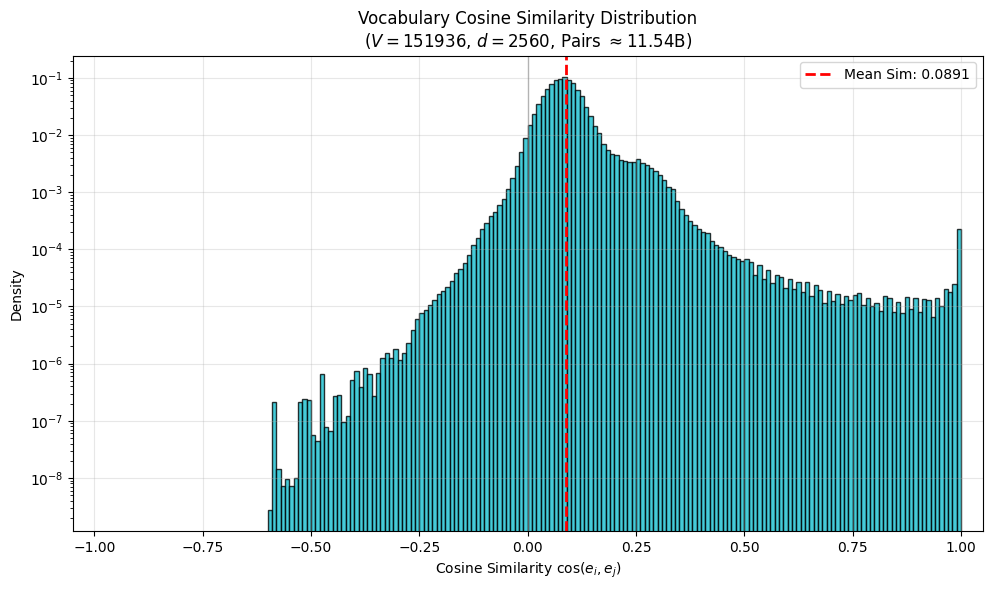

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

@torch.inference_mode()
def analyze_embedding_anisotropy(
    embed_weight: torch.Tensor,
    bins: int = 200,
    chunk_size: int = 2048,
) -> dict:
    """
    Computes the exact pairwise cosine similarity distribution of all tokens.
    Uses chunked operations and CPU fallback for histc to prevent MPS buffer errors.
    """
    V, d = embed_weight.shape
    device = embed_weight.device
    
    # 1. L2 Normalize all embeddings
    E_norm = embed_weight / embed_weight.norm(dim=-1, keepdim=True)
    
    # Pre-allocate histogram and sum on CPU (float64 to avoid precision loss)
    hist_counts = torch.zeros(bins, dtype=torch.float32, device="cpu")
    total_sum = 0.0
    
    bin_edges = torch.linspace(-1.0, 1.0, steps=bins + 1, device="cpu")

    # 2. Chunked Matrix Multiplication
    for i in tqdm(range(0, V, chunk_size), desc="Computing similarities"):
        chunk = E_norm[i : i + chunk_size]
        
        # Matrix multiplication happens fast on MPS/GPU
        # sims shape: [chunk_size, V]
        sims = torch.matmul(chunk, E_norm.T)
        
        # Accumulate exact sum (keep computation on device, extract item)
        total_sum += sims.sum(dtype=torch.float32).item()
        
        # Move the relatively small 'sims' matrix to CPU to compute histogram
        # This completely avoids the MPS "Invalid buffer size" issue
        sims_cpu = sims.cpu().float()
        chunk_hist = torch.histc(sims_cpu, bins=bins, min=-1.0, max=1.0)
        hist_counts += chunk_hist.to(torch.float32)

        # Free MPS memory explicitly (useful for Apple Silicon)
        del sims, chunk
        if device.type == "mps":
            torch.mps.empty_cache()

    # 3. Correct for diagonal and symmetry
    hist_counts[-1] -= V      # Remove the 1.0s from identical token pairs
    hist_counts /= 2.0        # Remove symmetric duplicates
    
    total_unique_pairs = (V * (V - 1)) / 2
    exact_mean_sim = (total_sum - V) / 2.0 / total_unique_pairs

    # 4. Convert for plotting
    hist_counts_np = hist_counts.numpy()
    bin_edges_np = bin_edges.numpy()
    bin_centers = (bin_edges_np[:-1] + bin_edges_np[1:]) / 2

    # 5. Visualization
    plt.figure(figsize=(10, 6))
    pdf = hist_counts_np / total_unique_pairs
    
    plt.bar(bin_centers, pdf, width=(2.0/bins), color="tab:cyan", edgecolor="black", alpha=0.8)
    plt.axvline(exact_mean_sim, color="red", linestyle="dashed", linewidth=2, 
                label=f"Mean Sim: {exact_mean_sim:.4f}")
    plt.axvline(0.0, color="gray", linestyle="-", linewidth=1, alpha=0.5)
    
    plt.title(f"Vocabulary Cosine Similarity Distribution\n($V={V}$, $d={d}$, Pairs $\\approx {total_unique_pairs/1e9:.2f}$B)")
    plt.xlabel("Cosine Similarity $\\cos(e_i, e_j)$")
    plt.ylabel("Density")
    plt.xlim(-1.05, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.yscale("log")  # Log scale to better visualize tail
    plt.show()

    return {
        "mean_similarity": exact_mean_sim,
        "hist_counts": hist_counts_np,
        "bin_centers": bin_centers,
        "total_pairs": total_unique_pairs
    }

# Example usage:
embedding_layer = model.get_input_embeddings()
results = analyze_embedding_anisotropy(embedding_layer.weight)

Running Gaussian compatibility tests on 100000 tokens...


Testing tokens:   0%|          | 0/100000 [00:00<?, ?it/s]/var/folders/8h/m_fyh66x1rg5byxx6gxyx1280000gn/T/ipykernel_15827/614244860.py:90: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result_ad = scipy_stats.anderson(emb)
Testing tokens: 100%|██████████| 100000/100000 [01:37<00:00, 1023.33it/s]


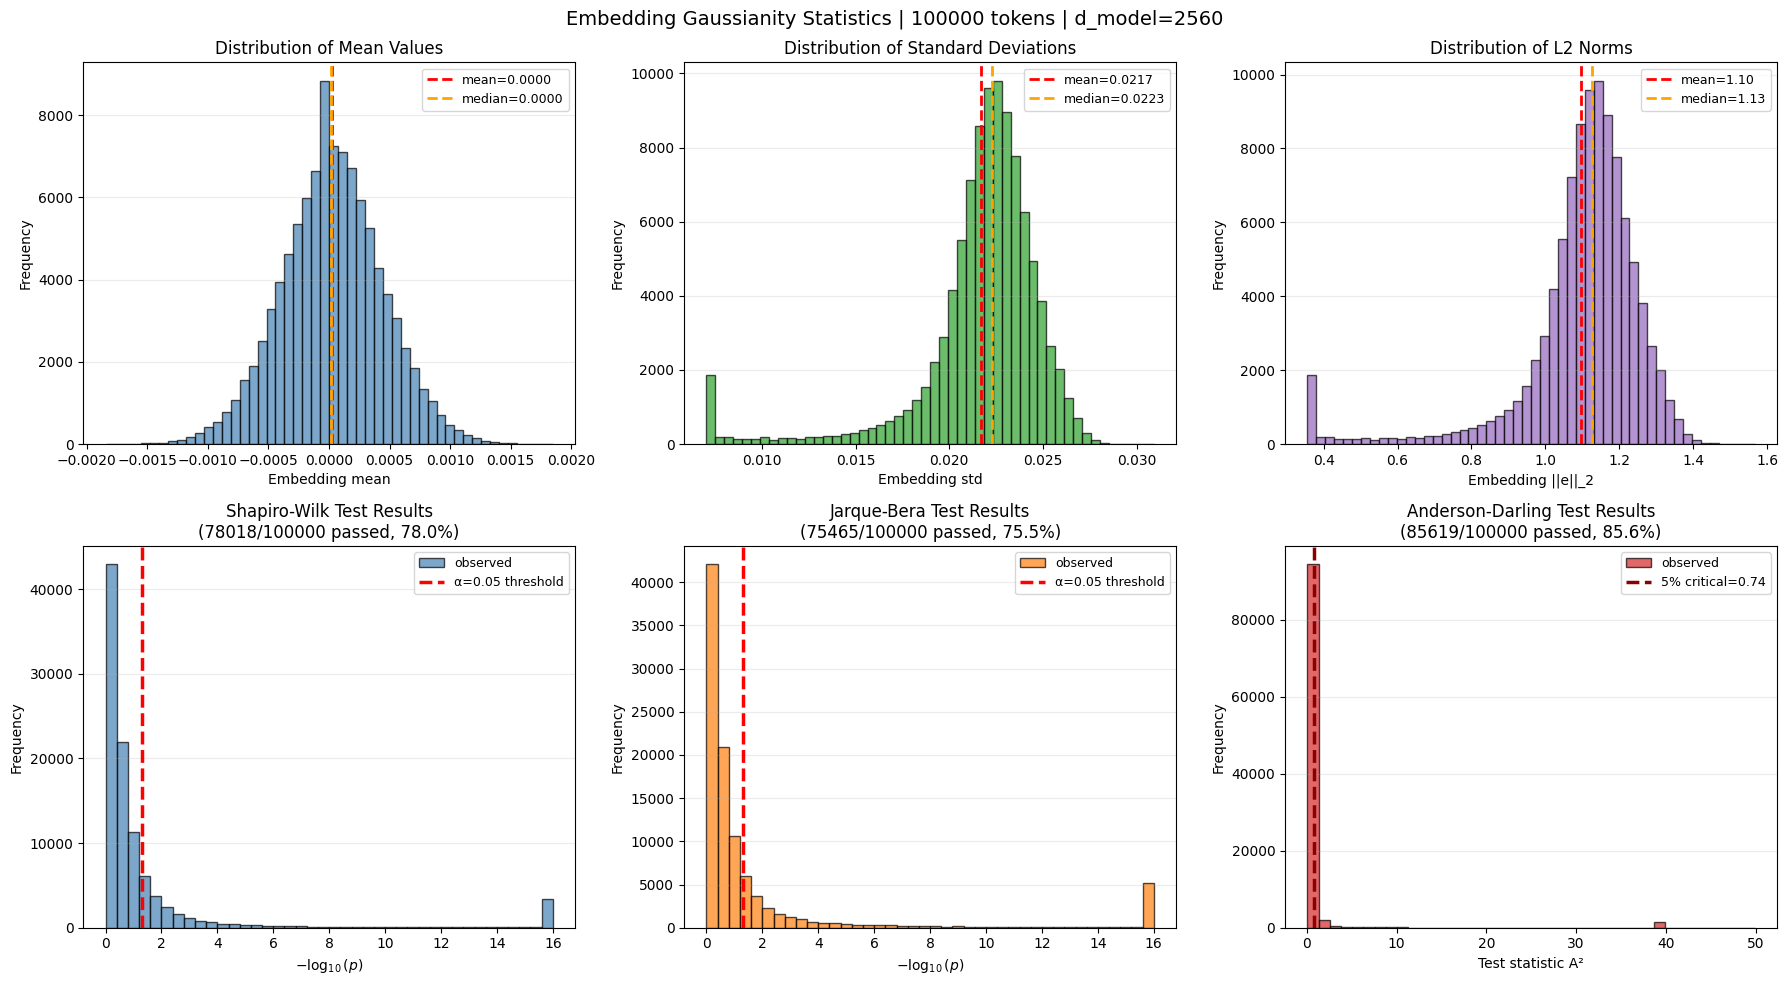


GAUSSIAN COMPATIBILITY TEST SUMMARY

Tested 100000 random embedding vectors (d_model=2560)
Significance level α = 0.05

----------------------------------------------------------------------------------------------------
Test Results:
----------------------------------------------------------------------------------------------------
Test                      Passed          Total           Pass Rate      
----------------------------------------------------------------------------------------------------
Shapiro-Wilk              78018           100000           78.02%
Jarque-Bera               75465           100000           75.47%
Anderson-Darling          85619           100000           85.62%

----------------------------------------------------------------------------------------------------
Embedding Vector Statistics:
----------------------------------------------------------------------------------------------------
Metric                    Mean            Std             

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from tqdm.auto import tqdm


@torch.inference_mode()
def analyze_embedding_gaussianity_statistics(
    model,
    tokenizer,
    n_tokens: int = 1000,
    seed: int = 42,
    alpha: float = 0.05,
) -> dict:
    """
    Run Gaussian compatibility tests on many embedding vectors and collect statistics.
    
    Tests performed (per token embedding vector):
      - Shapiro-Wilk:      p > α suggests the distribution is Gaussian
      - Anderson-Darling:  Lower statistic suggests better Gaussian fit
      - Jarque-Bera:       p > α suggests skewness & kurtosis are Gaussian-compatible
    
    Parameters
    ----------
    n_tokens : int, number of random tokens to test
    alpha    : float, significance level for hypothesis tests
    
    Returns
    -------
    dict with:
      - pass_counts:  number of tokens passing each test
      - test_results: raw test statistics for all tokens
      - means:        embedding vector means (shape [n_tokens])
      - stds:         embedding vector stds (shape [n_tokens])
      - norms:        L2 norms of embedding vectors
      - plot_data:    pre-computed data for visualization
    """
    model.eval()
    device = next(model.parameters()).device

    embed_matrix = model.get_input_embeddings().weight.detach().float().cpu()
    vocab_size, d_model = embed_matrix.shape

    rng = np.random.default_rng(seed)
    token_ids = rng.integers(0, vocab_size, size=n_tokens, dtype=np.int64)

    # Extract embedding vectors: shape [n_tokens, d_model]
    embeddings = embed_matrix[token_ids].numpy()

    # =========================================================================
    # Initialize arrays for test statistics
    # =========================================================================
    shapiro_stats = np.zeros(n_tokens)
    shapiro_pvals = np.zeros(n_tokens)
    anderson_stats = np.zeros(n_tokens)
    jarque_bera_stats = np.zeros(n_tokens)
    jarque_bera_pvals = np.zeros(n_tokens)
    
    means = np.zeros(n_tokens)
    stds = np.zeros(n_tokens)
    norms = np.zeros(n_tokens)
    skewness = np.zeros(n_tokens)
    kurtosis = np.zeros(n_tokens)

    # =========================================================================
    # Run tests for each token
    # =========================================================================
    print(f"Running Gaussian compatibility tests on {n_tokens} tokens...")
    for i in tqdm(range(n_tokens), desc="Testing tokens"):
        emb = embeddings[i]

        # Basic statistics
        means[i] = emb.mean()
        stds[i] = emb.std()
        norms[i] = np.linalg.norm(emb)
        skewness[i] = scipy_stats.skew(emb)
        kurtosis[i] = scipy_stats.kurtosis(emb)

        # Shapiro-Wilk test (subsample if too large)
        if len(emb) <= 5000:
            stat_sw, pval_sw = scipy_stats.shapiro(emb)
        else:
            subsample = rng.choice(emb, size=5000, replace=False)
            stat_sw, pval_sw = scipy_stats.shapiro(subsample)
        shapiro_stats[i] = stat_sw
        shapiro_pvals[i] = pval_sw

        # Anderson-Darling test
        result_ad = scipy_stats.anderson(emb)
        anderson_stats[i] = result_ad.statistic

        # Jarque-Bera test
        stat_jb, pval_jb = scipy_stats.jarque_bera(emb)
        jarque_bera_stats[i] = stat_jb
        jarque_bera_pvals[i] = pval_jb

    # =========================================================================
    # Compute pass counts (tests where p > alpha)
    # =========================================================================
    shapiro_passes = np.sum(shapiro_pvals > alpha)
    jarque_bera_passes = np.sum(jarque_bera_pvals > alpha)
    
    # Anderson-Darling: lower is better (use critical value at 5% level)
    # For large samples, critical value ≈ 0.74
    anderson_critical_5pct = 0.74
    anderson_passes = np.sum(anderson_stats < anderson_critical_5pct)

    pass_counts = {
        "Shapiro-Wilk": {
            "passed": shapiro_passes,
            "total": n_tokens,
            "pass_rate": 100.0 * shapiro_passes / n_tokens,
        },
        "Jarque-Bera": {
            "passed": jarque_bera_passes,
            "total": n_tokens,
            "pass_rate": 100.0 * jarque_bera_passes / n_tokens,
        },
        "Anderson-Darling": {
            "passed": anderson_passes,
            "total": n_tokens,
            "pass_rate": 100.0 * anderson_passes / n_tokens,
        },
    }

    # =========================================================================
    # Visualization
    # =========================================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        f"Embedding Gaussianity Statistics | {n_tokens} tokens | d_model={d_model}",
        fontsize=14,
    )

    # ── [0,0] Means distribution ──────────────────────────────────────────────
    ax = axes[0, 0]
    ax.hist(means, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
    ax.axvline(means.mean(), color="red", lw=2, ls="--", label=f"mean={means.mean():.4f}")
    ax.axvline(np.median(means), color="orange", lw=2, ls="--", label=f"median={np.median(means):.4f}")
    ax.set_title("Distribution of Mean Values")
    ax.set_xlabel("Embedding mean")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")

    # ── [0,1] Stds distribution ───────────────────────────────────────────────
    ax = axes[0, 1]
    ax.hist(stds, bins=50, color="tab:green", edgecolor="black", alpha=0.7)
    ax.axvline(stds.mean(), color="red", lw=2, ls="--", label=f"mean={stds.mean():.4f}")
    ax.axvline(np.median(stds), color="orange", lw=2, ls="--", label=f"median={np.median(stds):.4f}")
    ax.set_title("Distribution of Standard Deviations")
    ax.set_xlabel("Embedding std")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")

    # ── [0,2] L2 Norms distribution ───────────────────────────────────────────
    ax = axes[0, 2]
    ax.hist(norms, bins=50, color="tab:purple", edgecolor="black", alpha=0.7)
    ax.axvline(norms.mean(), color="red", lw=2, ls="--", label=f"mean={norms.mean():.2f}")
    ax.axvline(np.median(norms), color="orange", lw=2, ls="--", label=f"median={np.median(norms):.2f}")
    ax.set_title("Distribution of L2 Norms")
    ax.set_xlabel("Embedding ||e||_2")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")

    # ── [1,0] Shapiro-Wilk p-values ───────────────────────────────────────────
    ax = axes[1, 0]
    ax.hist(-np.log10(shapiro_pvals + 1e-16), bins=40, 
            color="steelblue", edgecolor="black", alpha=0.7, label="observed")
    ax.axvline(-np.log10(alpha), color="red", lw=2.5, ls="--", 
               label=f"α={alpha} threshold")
    ax.set_title(f"Shapiro-Wilk Test Results\n({shapiro_passes}/{n_tokens} passed, {pass_counts['Shapiro-Wilk']['pass_rate']:.1f}%)")
    ax.set_xlabel("$-\\log_{10}(p)$")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")

    # ── [1,1] Jarque-Bera p-values ────────────────────────────────────────────
    ax = axes[1, 1]
    ax.hist(-np.log10(jarque_bera_pvals + 1e-16), bins=40,
            color="tab:orange", edgecolor="black", alpha=0.7, label="observed")
    ax.axvline(-np.log10(alpha), color="red", lw=2.5, ls="--", 
               label=f"α={alpha} threshold")
    ax.set_title(f"Jarque-Bera Test Results\n({jarque_bera_passes}/{n_tokens} passed, {pass_counts['Jarque-Bera']['pass_rate']:.1f}%)")
    ax.set_xlabel("$-\\log_{10}(p)$")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")

    # ── [1,2] Anderson-Darling statistics ─────────────────────────────────────
    ax = axes[1, 2]
    ax.hist(anderson_stats, bins=40, color="tab:red", edgecolor="black", alpha=0.7, label="observed")
    ax.axvline(anderson_critical_5pct, color="darkred", lw=2.5, ls="--",
               label=f"5% critical={anderson_critical_5pct:.2f}")
    ax.set_title(f"Anderson-Darling Test Results\n({anderson_passes}/{n_tokens} passed, {pass_counts['Anderson-Darling']['pass_rate']:.1f}%)")
    ax.set_xlabel("Test statistic A²")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # Print summary report
    # =========================================================================
    print("\n" + "=" * 100)
    print("GAUSSIAN COMPATIBILITY TEST SUMMARY")
    print("=" * 100)
    print(f"\nTested {n_tokens} random embedding vectors (d_model={d_model})")
    print(f"Significance level α = {alpha}")
    print("\n" + "-" * 100)
    print("Test Results:")
    print("-" * 100)
    print(f"{'Test':<25} {'Passed':<15} {'Total':<15} {'Pass Rate':<15}")
    print("-" * 100)
    for test_name, results in pass_counts.items():
        print(f"{test_name:<25} {results['passed']:<15} {results['total']:<15} "
              f"{results['pass_rate']:>6.2f}%")

    print("\n" + "-" * 100)
    print("Embedding Vector Statistics:")
    print("-" * 100)
    print(f"{'Metric':<25} {'Mean':<15} {'Std':<15} {'Min':<15} {'Max':<15}")
    print("-" * 100)
    
    stats_dict = {
        "Means": means,
        "Stds": stds,
        "L2 Norms": norms,
        "Skewness": skewness,
        "Kurtosis": kurtosis,
    }
    
    for name, vals in stats_dict.items():
        print(f"{name:<25} {vals.mean():>14.5f} {vals.std():>14.5f} "
              f"{vals.min():>14.5f} {vals.max():>14.5f}")

    print("\n" + "=" * 100)
    print("INTERPRETATION:")
    print("  - High pass rate (>80%) → Embeddings are approximately Gaussian-distributed")
    print("  - Low pass rate (<50%) → Embeddings deviate from Gaussian (possibly uniform or heavy-tailed)")
    print("  - Skewness near 0      → Symmetric distribution (Gaussian-like)")
    print("  - Kurtosis near 0      → Tail behavior similar to Gaussian")
    print("=" * 100 + "\n")

    # Return comprehensive results
    return {
        "pass_counts": pass_counts,
        "n_tokens": n_tokens,
        "d_model": d_model,
        "test_results": {
            "shapiro_stats": shapiro_stats,
            "shapiro_pvals": shapiro_pvals,
            "anderson_stats": anderson_stats,
            "jarque_bera_stats": jarque_bera_stats,
            "jarque_bera_pvals": jarque_bera_pvals,
        },
        "embedding_stats": {
            "means": means,
            "stds": stds,
            "norms": norms,
            "skewness": skewness,
            "kurtosis": kurtosis,
        },
    }


# Example usage:
gaussianity_results = analyze_embedding_gaussianity_statistics(
    model, 
    tokenizer, 
    n_tokens=100_000, 
    seed=42,
    alpha=0.05,
)
